<a href="https://colab.research.google.com/github/Vledhint/maestria-ia-act2/blob/main/SCA_Banking77_Transformers_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad: Transformers y Modelos de Lenguaje Grande (LLM)
### Sistemas Cognitivos Artificiales · Clasificación de intenciones bancarias (Banking77)

**Objetivo.** Ajustar (*fine-tuning*) un Transformer **DistilRoBERTa** para clasificar consultas bancarias en 77 intenciones, evaluar su desempeño con métricas estándar y, después, diseñar y calibrar un *prompt* para **Falcon-7b-instruct** que explique en lenguaje natural por qué el clasificador se equivocó, controlando las alucinaciones con la temperatura, la longitud máxima de respuesta y la estructura del *prompt*.

**Estructura del notebook**

| Sección | Contenido | Criterio de la rúbrica |
|---|---|---|
| 1 | Configuración del entorno y carga del dataset | 5 |
| 2 | Análisis exploratorio de datos (EDA) | 1 (15 %) |
| 3 | Clasificación con DistilRoBERTa | 2 (25 %) |
| 4 | Diseño y calibración del *prompt* con Falcon-7b-instruct | 3 (30 %) |
| 5 | Conclusiones generales | 4 (20 %) |
| 6 | Referencias | 5 (10 %) |

> **Entorno recomendado:** Google Colab con GPU (T4 o superior). Las secciones 1–3 también corren en CPU (el *fine-tuning* tarda unos 40–60 min en una CPU de 12 hilos). La sección 4 **necesita GPU**: Falcon-7b tiene unos 7 200 millones de parámetros.

## 1. Configuración del entorno

### 1.1 Verificación de hardware
El enunciado pide comprobar la VRAM disponible con `nvidia-smi` (mínimo 15 GB libres para Falcon-7b en media precisión). Si la GPU tiene menos memoria (una T4 ofrece ~15 GB en total), más adelante se carga Falcon cuantizado a 4 bits con `bitsandbytes`.

In [1]:
# Muestra la GPU disponible y su memoria (si no hay GPU, se indica y se continúa en CPU).
import shutil, subprocess

if shutil.which("nvidia-smi"):
    print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)
else:
    print("nvidia-smi no disponible: no se detectó GPU NVIDIA. Las secciones 1-3 correrán en CPU.")

Wed Sep 30 23:43:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 1.2 Instalación de dependencias
Colab ya trae `torch`, `transformers`, `scikit-learn`, `pandas` y `matplotlib`, así que solo se instalan los paquetes que faltan. `bitsandbytes` permite cargar Falcon-7b en 4 bits en GPUs con menos de 16 GB.

> **Nota sobre NumPy (enunciado).** El error `ValueError: Unable to avoid copy while creating an array as requested…` aparece al combinar NumPy 2.x con versiones antiguas de `transformers`/`datasets`. Con versiones actuales (`transformers ≥ 4.45`, `datasets ≥ 3`) no ocurre. Si aparece en un entorno con Python ≤ 3.11, la solución sugerida es `pip install "numpy<=1.24.3"` junto con versiones compatibles de las demás bibliotecas y reiniciar el kernel. Con Python 3.12 (Colab actual) NumPy 1.24 no está disponible y lo correcto es actualizar `transformers` y `datasets`.

In [2]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Solo en Colab: paquetes que no vienen preinstalados.
    %pip install -q "datasets>=3.0" "accelerate>=0.30" wordcloud nltk bitsandbytes
else:
    print("Entorno local: instala las dependencias con `pip install -r requirements.txt`.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 14.0 MB/s eta 0:00:00


### 1.3 Importaciones y configuración global
Se fija una semilla para que los resultados sean reproducibles. Hay dos variables de entorno pensadas **solo para pruebas rápidas** del código (en Colab no hace falta tocarlas):
- `FAST_DEV_RUN=1`: entrena con un subconjunto pequeño durante 1 época.
- `FORCE_RUN_LLM=1` + `LLM_MODEL_ID=<modelo>`: ejecuta la sección 4 sin GPU usando un modelo diminuto.

In [3]:
import gc
import json
import os
import random
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FAST_DEV_RUN = os.environ.get("FAST_DEV_RUN") == "1"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"torch {torch.__version__} | dispositivo: {DEVICE} | FAST_DEV_RUN={FAST_DEV_RUN}")

torch 2.11.0+cu128 | dispositivo: cuda | FAST_DEV_RUN=False


### 1.4 Funciones auxiliares
Estas funciones se reutilizan en todo el notebook. Son puras (no dependen de variables globales), llevan *type hints* y tienen pruebas unitarias en `tests/` que se ejecutan con `pytest`. Hay dos patrones de diseño:
- **Builder** (`PromptBuilder`): arma el *prompt* paso a paso (rol, reglas, ejemplos *few-shot*, plantilla). Así se comparan variantes del *prompt* sin duplicar código.
- **Strategy** (`DecodingConfig`): cada configuración de decodificación (temperatura, longitud, *top-p*) es una estrategia intercambiable que se pasa a `generate()`, lo que simplifica la búsqueda de calibración.

In [4]:
from dataclasses import dataclass, field
from itertools import combinations

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support


# ----------------------------------------------------------------------------
# Utilidades de texto para el EDA
# ----------------------------------------------------------------------------
def clean_text(text: str) -> str:
    """Pasa a minúsculas y elimina todo lo que no sea letra o espacio."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)  # quita dígitos, signos y caracteres especiales
    return re.sub(r"\s+", " ", text).strip()


def tokenize_clean(text: str, stopwords: set[str], min_len: int = 2) -> list[str]:
    """Limpia el texto y devuelve los tokens que no son stopwords."""
    return [tok for tok in clean_text(text).split() if tok not in stopwords and len(tok) >= min_len]


def top_ngrams(token_lists: list[list[str]], n: int, k: int) -> list[tuple[str, int]]:
    """Devuelve los k n-gramas más frecuentes (n=1 palabras, 2 bigramas, 3 trigramas)."""
    counter: Counter[str] = Counter()
    for tokens in token_lists:
        counter.update(" ".join(tokens[i:i + n]) for i in range(len(tokens) - n + 1))
    return counter.most_common(k)


def class_balance_summary(counts: pd.Series) -> dict[str, float]:
    """Resume el balance de clases: extremos, razón de desbalance, CV y entropía normalizada."""
    p = counts / counts.sum()
    entropy = float(-(p * np.log(p)).sum() / np.log(len(counts)))
    return {
        "n_clases": int(len(counts)),
        "min": int(counts.min()),
        "max": int(counts.max()),
        "media": float(counts.mean()),
        "razon_desbalance": float(counts.max() / counts.min()),
        "coef_variacion": float(counts.std() / counts.mean()),
        "entropia_normalizada": entropy,
    }


def humanize_label(label: str) -> str:
    """Convierte 'card_arrival' en 'card arrival' (más natural para el LLM)."""
    return re.sub(r"\s+", " ", label.replace("_", " ").replace("?", "")).strip().lower()


# ----------------------------------------------------------------------------
# Análisis de errores del clasificador
# ----------------------------------------------------------------------------
def per_class_table(y_true: np.ndarray, y_pred: np.ndarray, label_names: list[str]) -> pd.DataFrame:
    """Métricas por clase + conteo de errores (FN: mal clasificadas de esa clase, FP: atribuidas por error)."""
    labels = list(range(len(label_names)))
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tp = np.diag(cm)
    return pd.DataFrame({
        "clase": label_names,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "soporte": support,
        "aciertos": tp,
        "errores_FN": support - tp,
        "falsos_positivos_FP": cm.sum(axis=0) - tp,
    })


def top_confused_pairs(y_true: np.ndarray, y_pred: np.ndarray, label_names: list[str], k: int = 15) -> pd.DataFrame:
    """Pares (clase real -> clase predicha) con más confusiones."""
    pairs = Counter((label_names[t], label_names[p]) for t, p in zip(y_true, y_pred) if t != p)
    rows = [{"real": r, "predicha": pr, "errores": c} for (r, pr), c in pairs.most_common(k)]
    return pd.DataFrame(rows, columns=["real", "predicha", "errores"])


def select_misclassified(errors: pd.DataFrame, n: int = 20) -> pd.DataFrame:
    """Elige n errores diversos: uno por par (real, predicha), empezando por los pares más frecuentes
    y, dentro de cada par, el error con mayor confianza del modelo (los errores "seguros" son los más
    interesantes de explicar). Si faltan pares, completa con los errores restantes más confiados.

    `errors` debe tener las columnas: text, true_label, pred_label, confidence.
    """
    pair_freq = errors.groupby(["true_label", "pred_label"]).size().rename("pair_freq")
    ranked = (errors.join(pair_freq, on=["true_label", "pred_label"])
                    .sort_values(["pair_freq", "confidence"], ascending=[False, False]))
    first_of_pair = ranked.drop_duplicates(["true_label", "pred_label"])
    chosen = first_of_pair.head(n)
    if len(chosen) < n:
        rest = ranked.drop(chosen.index).sort_values("confidence", ascending=False)
        chosen = pd.concat([chosen, rest.head(n - len(chosen))])
    return chosen.drop(columns="pair_freq").reset_index(drop=True)


# ----------------------------------------------------------------------------
# Prompt engineering (Builder) y decodificación (Strategy)
# ----------------------------------------------------------------------------
@dataclass(frozen=True)
class DecodingConfig:
    """Estrategia de decodificación. temperature=0 equivale a búsqueda codiciosa (determinista)."""
    temperature: float = 0.0
    max_new_tokens: int = 60
    top_p: float = 0.9
    repetition_penalty: float = 1.15

    def to_generate_kwargs(self) -> dict[str, object]:
        """Traduce la estrategia a argumentos de `model.generate()`."""
        kwargs: dict[str, object] = {
            "max_new_tokens": self.max_new_tokens,
            "repetition_penalty": self.repetition_penalty,
        }
        if self.temperature <= 0:
            kwargs["do_sample"] = False
        else:
            kwargs.update(do_sample=True, temperature=self.temperature, top_p=self.top_p)
        return kwargs

    @property
    def name(self) -> str:
        return f"T={self.temperature:g} | max_new_tokens={self.max_new_tokens}"


@dataclass
class PromptBuilder:
    """Arma prompts con el formato de conversación de Falcon-instruct:
    "<sistema>\n\nUser: <mensaje>\n\nAssistant: <respuesta>" (mismo formato que su chat template)."""
    system: str = ""
    rules: list[str] = field(default_factory=list)
    examples: list[tuple[str, str]] = field(default_factory=list)  # (mensaje_usuario, respuesta)
    template: str = "{query}"

    def with_system(self, text: str) -> "PromptBuilder":
        self.system = text.strip()
        return self

    def with_rule(self, rule: str) -> "PromptBuilder":
        self.rules.append(rule.strip())
        return self

    def with_example(self, user_message: str, answer: str) -> "PromptBuilder":
        self.examples.append((user_message.strip(), answer.strip()))
        return self

    def with_template(self, template: str) -> "PromptBuilder":
        self.template = template.strip()
        return self

    def build(self, **fields: str) -> str:
        """Devuelve el prompt final; termina en 'Assistant:' para que el modelo complete la respuesta."""
        header = self.system
        if self.rules:
            header += "\nRules:\n" + "\n".join(f"- {r}" for r in self.rules)
        turns = [header.strip()] if header.strip() else []
        for user_message, answer in self.examples:
            turns.append(f"User: {user_message}\n\nAssistant: {answer}")
        turns.append(f"User: {self.template.format(**fields)}\n\nAssistant:")
        return "\n\n".join(turns)


# ----------------------------------------------------------------------------
# Post-procesamiento y evaluación automática de las explicaciones
# ----------------------------------------------------------------------------
_SENTENCE_SPLIT = re.compile(r"(?<=[.!?])\s+")
_STOP_MARKERS = ("\nUser:", "\nAssistant:", "\n\n", "Customer query:")


def split_sentences(text: str) -> list[str]:
    """Separa en oraciones por signos de puntuación final."""
    return [s for s in _SENTENCE_SPLIT.split(text.strip()) if s]


def clean_explanation(raw: str, max_sentences: int = 2) -> str:
    """Corta la generación en el primer marcador de un nuevo turno y conserva máx. `max_sentences`."""
    text = raw
    for marker in _STOP_MARKERS:
        idx = text.find(marker)
        if idx > 0:
            text = text[:idx]
    text = re.sub(r"\s+", " ", text).strip()
    return " ".join(split_sentences(text)[:max_sentences])


def _content_words(text: str, stopwords: set[str]) -> list[str]:
    return [w for w in clean_text(text).split() if w not in stopwords and len(w) > 2]


def explanation_metrics(raw: str, query: str, labels: list[str], stopwords: set[str],
                        allowed_vocab: set[str] | None = None, max_sentences: int = 2) -> dict[str, float]:
    """Métricas automáticas (aproximadas) de calidad de una explicación generada.

    - n_oraciones / cumple_longitud: ¿respeta el límite de oraciones (salida cruda)?
    - truncada: la salida cruda termina sin puntuación final -> max_new_tokens demasiado corto.
    - ratio_novedad: fracción de palabras de contenido que NO aparecen en la consulta, las etiquetas
      ni el vocabulario permitido. Es un *proxy* de alucinación: cuanto más alto, más "inventa".
    - repeticion: 1 - (palabras únicas / palabras totales).
    - menciona_consulta: ¿cita al menos una palabra de contenido de la consulta?
    """
    first_turn = raw
    for marker in _STOP_MARKERS:
        idx = first_turn.find(marker)
        if idx > 0:
            first_turn = first_turn[:idx]
    first_turn = first_turn.strip()
    sentences = split_sentences(first_turn)
    words = _content_words(first_turn, stopwords)
    query_words = set(_content_words(query, stopwords))
    grounded = query_words | {w for lab in labels for w in _content_words(lab, stopwords)} | (allowed_vocab or set())
    novel = [w for w in words if w not in grounded]
    all_tokens = clean_text(first_turn).split()
    return {
        "n_oraciones": float(len(sentences)),
        "cumple_longitud": float(0 < len(sentences) <= max_sentences),
        "truncada": float(bool(first_turn) and first_turn[-1] not in ".!?\"'"),
        "ratio_novedad": float(len(novel) / len(words)) if words else 1.0,
        "repeticion": float(1 - len(set(all_tokens)) / len(all_tokens)) if all_tokens else 0.0,
        "menciona_consulta": float(bool(query_words & set(words))),
    }


def quality_score(m: dict[str, float]) -> float:
    """Puntaje compuesto en [0, 1] para comparar configuraciones (más alto = mejor)."""
    return (0.25 * m["cumple_longitud"] + 0.20 * (1 - m["truncada"]) + 0.30 * (1 - m["ratio_novedad"])
            + 0.10 * (1 - min(1.0, 2 * m["repeticion"])) + 0.15 * m["menciona_consulta"])


REASON_KEYWORDS: dict[str, tuple[str, ...]] = {
    "Palabras clave compartidas / engañosas": ("word", "keyword", "term", "mention", "phrase", "contain", "uses", "says"),
    "Intenciones semánticamente similares": ("similar", "related", "overlap", "both", "close", "same"),
    "Consulta ambigua o sin contexto": ("ambiguous", "vague", "unclear", "general", "specific", "lack", "missing", "context"),
    "Confusión de estado del proceso": ("pending", "status", "waiting", "still", "failed", "declined", "revert", "arriv", "delay"),
    "Confusión de cargos, tarifas o tipo de cambio": ("fee", "charge", "cost", "rate", "exchange", "extra"),
    "Confusión de identidad / verificación": ("verify", "verification", "identity", "document"),
}


def categorize_reason(explanation: str) -> list[str]:
    """Asigna una o varias categorías de razón a una explicación mediante palabras clave."""
    text = explanation.lower()
    found = [cat for cat, kws in REASON_KEYWORDS.items() if any(kw in text for kw in kws)]
    return found or ["Otra"]


# ----------------------------------------------------------------------------
# Compatibilidad Falcon + bitsandbytes
# ----------------------------------------------------------------------------
def enable_bnb_for_falcon() -> bool:
    """Permite cuantizar Falcon con bitsandbytes en transformers recientes.

    `replace_with_bnb_linear` solo sustituye capas cuyo tipo es *exactamente* `nn.Linear`, pero Falcon
    usa `FalconLinear` (subclase con un forward equivalente: x @ W.T + b). Sin este ajuste no se cuantiza
    ninguna capa: aparece el aviso "...using eetq but no linear modules were found..." y el modelo se
    carga completo en 16 bits (~14 GB). Debe llamarse ANTES de `from_pretrained`.
    Devuelve True si aplicó el cambio y False si ya estaba aplicado.
    """
    import torch.nn as nn
    from transformers.models.falcon import modeling_falcon

    if modeling_falcon.FalconLinear is nn.Linear:
        return False
    modeling_falcon.FalconLinear = nn.Linear
    return True


def count_4bit_linears(model: "object") -> int:
    """Cuenta las capas cuantizadas a 4 bits (bitsandbytes.nn.Linear4bit) de un modelo."""
    import bitsandbytes as bnb

    return sum(isinstance(m, bnb.nn.Linear4bit) for m in model.modules())

### 1.5 Carga del dataset *PolyAI/banking77*
Desde `datasets` 4.0, Hugging Face ya no ejecuta *scripts* de carga, y `PolyAI/banking77` depende de uno (`banking77.py`). Por eso se intenta primero la carga estándar y, si falla, se leen los **mismos CSV oficiales** que descarga ese script (repositorio de PolyAI). Las etiquetas se ordenan igual que en el script (orden alfabético sin distinguir mayúsculas), así que los IDs coinciden con los de la versión del Hub.

In [5]:
from datasets import ClassLabel, Dataset, DatasetDict, load_dataset

POLYAI_URL = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/{split}.csv"


def load_banking77() -> DatasetDict:
    '''Carga Banking77 del Hub o, si no se puede, de los CSV oficiales con el mismo esquema.'''
    try:
        return load_dataset("PolyAI/banking77")
    except Exception as exc:  # datasets>=4 no soporta scripts de carga
        print(f"Carga estándar no disponible ({type(exc).__name__}); se usan los CSV oficiales de PolyAI.")
    frames = {s: pd.read_csv(POLYAI_URL.format(split=s)) for s in ("train", "test")}
    names = sorted(frames["train"]["category"].unique(), key=str.lower)  # mismo orden que banking77.py
    class_label = ClassLabel(names=names)
    splits = {}
    for split, frame in frames.items():
        ds = Dataset.from_dict({"text": frame["text"].tolist(),
                                "label": [class_label.str2int(c) for c in frame["category"]]})
        splits[split] = ds.cast_column("label", class_label)
    return DatasetDict(splits)


raw_ds = load_banking77()
LABEL_NAMES: list[str] = raw_ds["train"].features["label"].names
NUM_LABELS = len(LABEL_NAMES)
id2label = dict(enumerate(LABEL_NAMES))
label2id = {v: k for k, v in id2label.items()}

train_df = raw_ds["train"].to_pandas().assign(label_name=lambda d: d["label"].map(id2label))
test_df = raw_ds["test"].to_pandas().assign(label_name=lambda d: d["label"].map(id2label))

print(raw_ds)
print(f"\nClases: {NUM_LABELS} | train: {len(train_df):,} | test: {len(test_df):,}")
train_df.sample(8, random_state=SEED)

README.md:   0%|          | 0.00/9.78k [00:00<?, ?B/s]

banking77.py:   0%|          | 0.00/7.17k [00:00<?, ?B/s]

Carga estándar no disponible (RuntimeError); se usan los CSV oficiales de PolyAI.


Casting the dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/3080 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

Clases: 77 | train: 10,003 | test: 3,080


,text,label,label_name
6883,Is it possible for me to change my PIN number?,21,change_pin
5836,I'm not sure why my card didn't work,25,declined_card_payment
8601,I don't think my top up worked,59,top_up_failed
2545,Can you explain why my payment was charged a fee?,15,card_payment_fee_charged
8697,"How long does a transfer from a UK account take? I just made one and it doesn't seem to be working, wondering if eve...",5,balance_not_updated_after_bank_transfer
5573,Why am I getting declines when trying to make a purchase online?,27,declined_transfer
576,What is the $1 transaction on my account?,34,extra_charge_on_statement
6832,It looks like my card payment was sent back.,53,reverted_card_payment?


## 2. Análisis exploratorio de datos (EDA)

### 2.1 Longitud y número de palabras por consulta
Se calculan la longitud en caracteres y el número de palabras (separadas por espacios) de cada consulta, en ambos conjuntos.

In [6]:
for df in (train_df, test_df):
    df["n_chars"] = df["text"].str.len()
    df["n_words"] = df["text"].str.split().str.len()

desc = pd.concat(
    {"train": train_df[["n_chars", "n_words"]].describe().T,
     "test": test_df[["n_chars", "n_words"]].describe().T}
).round(2)
desc

count   mean    std   min   25%   50%   75%    max
train n_chars  10003.0  59.47  40.87  13.0  36.0  47.0  64.0  433.0
      n_words  10003.0  11.95   7.89   2.0   7.0  10.0  13.0   79.0
test  n_chars   3080.0  54.23  34.66  13.0  35.0  45.0  60.0  368.0
      n_words   3080.0  10.95   6.69   2.0   7.0   9.0  12.0   69.0

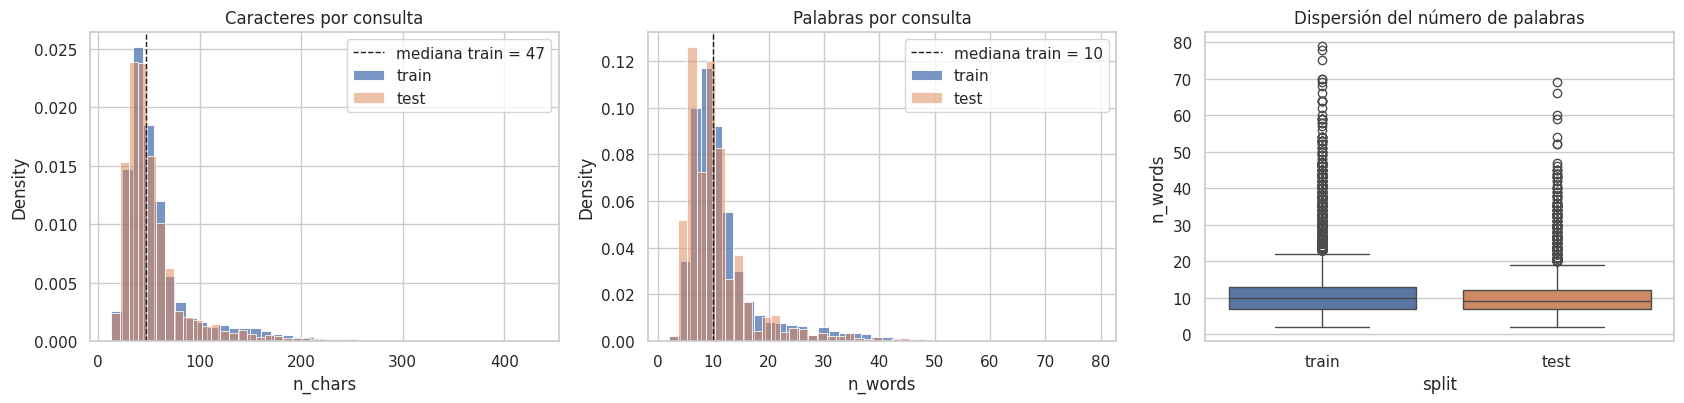

Asimetría (train): {'n_chars': 2.76, 'n_words': 2.61} | percentil 95 de palabras: 29


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for ax, col, title in zip(axes[:2], ["n_chars", "n_words"], ["Caracteres por consulta", "Palabras por consulta"]):
    sns.histplot(train_df[col], bins=40, ax=ax, color="#4C72B0", label="train", stat="density")
    sns.histplot(test_df[col], bins=40, ax=ax, color="#DD8452", label="test", stat="density", alpha=0.5)
    ax.axvline(train_df[col].median(), ls="--", c="k", lw=1, label=f"mediana train = {train_df[col].median():.0f}")
    ax.set_title(title); ax.legend()
sns.boxplot(data=pd.concat([train_df.assign(split="train"), test_df.assign(split="test")]),
            x="split", y="n_words", ax=axes[2], palette=["#4C72B0", "#DD8452"], hue="split", legend=False)
axes[2].set_title("Dispersión del número de palabras")
plt.tight_layout(); plt.show()

skew = train_df[["n_chars", "n_words"]].skew().round(2).to_dict()
p95 = train_df["n_words"].quantile(0.95)
print(f"Asimetría (train): {skew} | percentil 95 de palabras: {p95:.0f}")

### 2.2 Limpieza básica del texto
1. Conversión a minúsculas.
2. Eliminación de caracteres especiales, dígitos y signos de puntuación (expresión regular `[^a-z\s]`).
3. Eliminación de *stopwords* en inglés (lista de NLTK).

> Esta limpieza sirve **solo para el EDA**. El Transformer recibe el texto original: su *tokenizer* BPE ya maneja mayúsculas y puntuación, y las *stopwords* incluyen negaciones (*not*, *no*, *haven't*) que cambian la intención (*"my card is **not** working"*). Quitarlas le restaría información al modelo.

In [8]:
import nltk

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords as nltk_stopwords

STOPWORDS: set[str] = set(nltk_stopwords.words("english"))

train_df["clean"] = train_df["text"].map(clean_text)
train_df["tokens"] = train_df["text"].map(lambda t: tokenize_clean(t, STOPWORDS))
test_df["tokens"] = test_df["text"].map(lambda t: tokenize_clean(t, STOPWORDS))

n_before = train_df["text"].str.split().str.len().sum()
n_after = train_df["tokens"].str.len().sum()
print(f"Tokens antes: {n_before:,} | después: {n_after:,} ({1 - n_after / n_before:.1%} eliminados)")
print(f"Vocabulario limpio (train): {len(set(t for toks in train_df['tokens'] for t in toks)):,} términos")
train_df[["text", "clean", "tokens"]].head(6)

Tokens antes: 119,530 | después: 51,678 (56.8% eliminados)
Vocabulario limpio (train): 2,171 términos


,text,clean,tokens
0,I am still waiting on my card?,i am still waiting on my card,"[still, waiting, card]"
1,What can I do if my card still hasn't arrived after 2 weeks?,what can i do if my card still hasn t arrived after weeks,"[card, still, arrived, weeks]"
2,I have been waiting over a week. Is the card still coming?,i have been waiting over a week is the card still coming,"[waiting, week, card, still, coming]"
3,Can I track my card while it is in the process of delivery?,can i track my card while it is in the process of delivery,"[track, card, process, delivery]"
4,"How do I know if I will get my card, or if it is lost?",how do i know if i will get my card or if it is lost,"[know, get, card, lost]"
5,When did you send me my new card?,when did you send me my new card,"[send, new, card]"


### 2.3 Palabras, bigramas y trigramas más frecuentes
Se calculan sobre el conjunto de entrenamiento limpio.

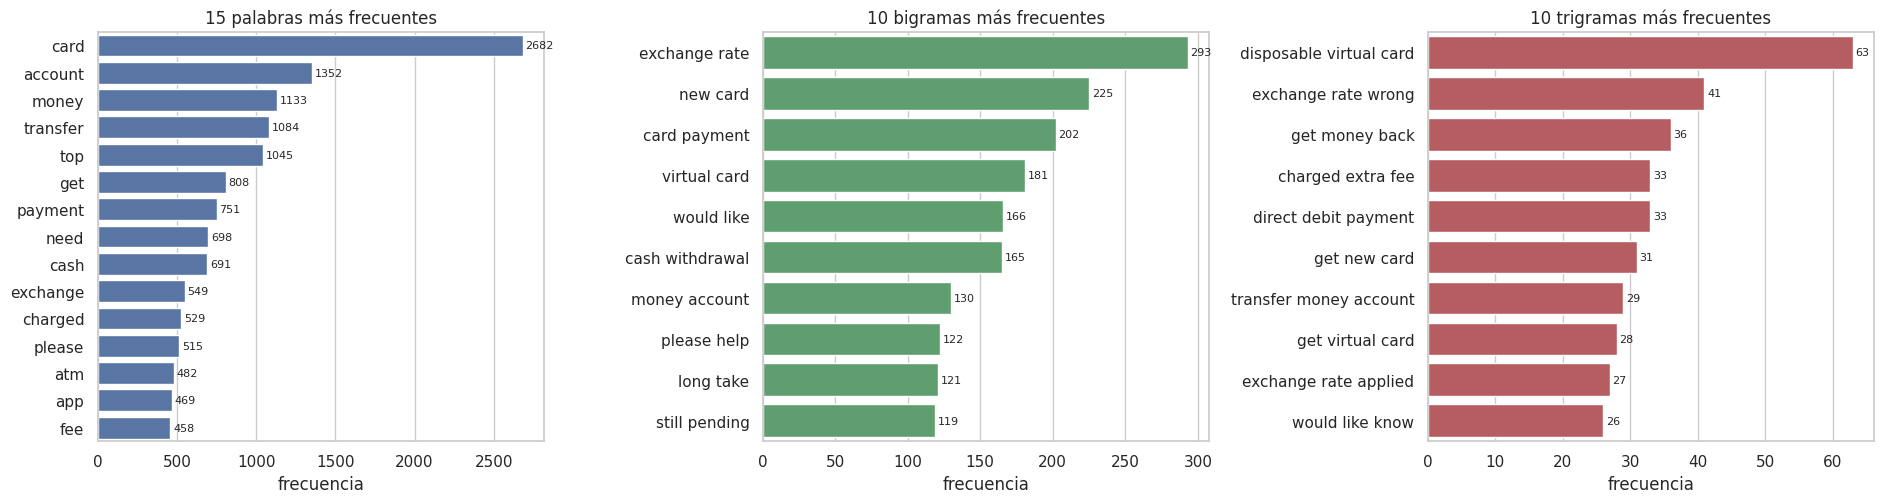

,palabra,frecuencia,bigrama,frecuencia,trigrama,frecuencia
0,card,2682,exchange rate,293.0,disposable virtual card,63.0
1,account,1352,new card,225.0,exchange rate wrong,41.0
2,money,1133,card payment,202.0,get money back,36.0
3,transfer,1084,virtual card,181.0,charged extra fee,33.0
4,top,1045,would like,166.0,direct debit payment,33.0
5,get,808,cash withdrawal,165.0,get new card,31.0
6,payment,751,money account,130.0,transfer money account,29.0
7,need,698,please help,122.0,get virtual card,28.0
8,cash,691,long take,121.0,exchange rate applied,27.0
9,exchange,549,still pending,119.0,would like know,26.0


In [9]:
token_lists = train_df["tokens"].tolist()
top_words = pd.DataFrame(top_ngrams(token_lists, 1, 15), columns=["palabra", "frecuencia"])
top_bigrams = pd.DataFrame(top_ngrams(token_lists, 2, 10), columns=["bigrama", "frecuencia"])
top_trigrams = pd.DataFrame(top_ngrams(token_lists, 3, 10), columns=["trigrama", "frecuencia"])

fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
for ax, data, col, title, color in [
    (axes[0], top_words, "palabra", "15 palabras más frecuentes", "#4C72B0"),
    (axes[1], top_bigrams, "bigrama", "10 bigramas más frecuentes", "#55A868"),
    (axes[2], top_trigrams, "trigrama", "10 trigramas más frecuentes", "#C44E52"),
]:
    sns.barplot(data=data, y=col, x="frecuencia", ax=ax, color=color)
    ax.set_title(title); ax.set_ylabel("")
    ax.bar_label(ax.containers[0], padding=2, fontsize=8)
plt.tight_layout(); plt.show()

display(pd.concat([top_words, top_bigrams, top_trigrams], axis=1).fillna(""))

### 2.4 Nube de palabras

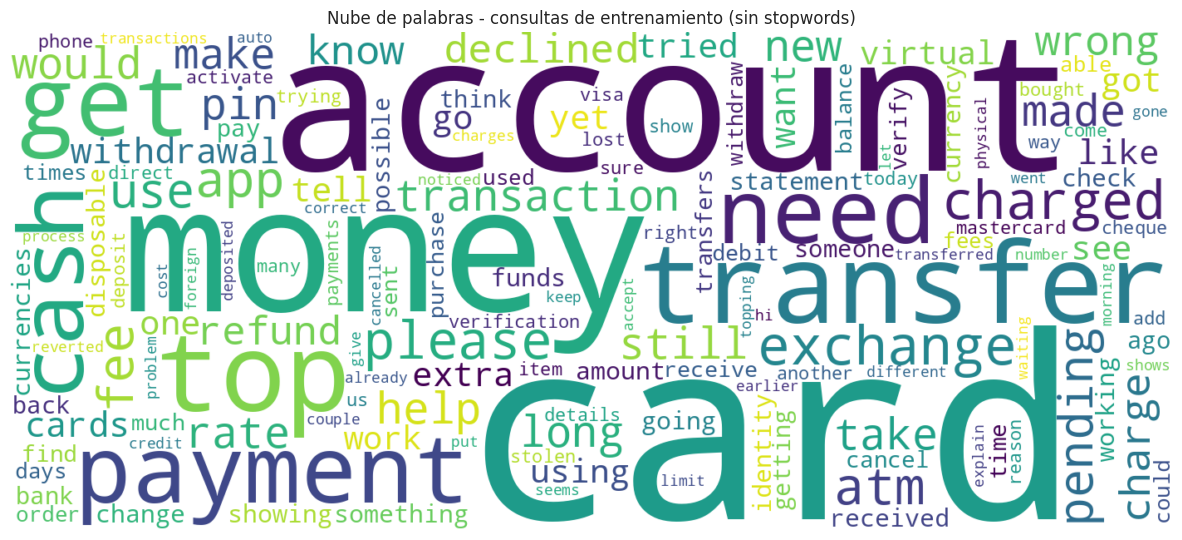

In [10]:
from wordcloud import WordCloud

freqs = Counter(t for toks in token_lists for t in toks)
wc = WordCloud(width=1400, height=600, background_color="white", colormap="viridis",
               max_words=150, random_state=SEED).generate_from_frequencies(freqs)
plt.figure(figsize=(15, 6.5))
plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
plt.title("Nube de palabras - consultas de entrenamiento (sin stopwords)")
plt.show()

### 2.5 ¿Está balanceado el conjunto de datos?
Se revisa la distribución de las 77 clases en *train* y *test* con tres indicadores: la razón de desbalance (clase más grande entre clase más pequeña), el coeficiente de variación de los conteos y la entropía normalizada (1 = distribución perfectamente uniforme).

,train,test
n_clases,77.000,77.0
min,35.000,40.0
max,187.000,40.0
media,129.909,40.0
razon_desbalance,5.343,1.0
coef_variacion,0.254,0.0
entropia_normalizada,0.992,1.0


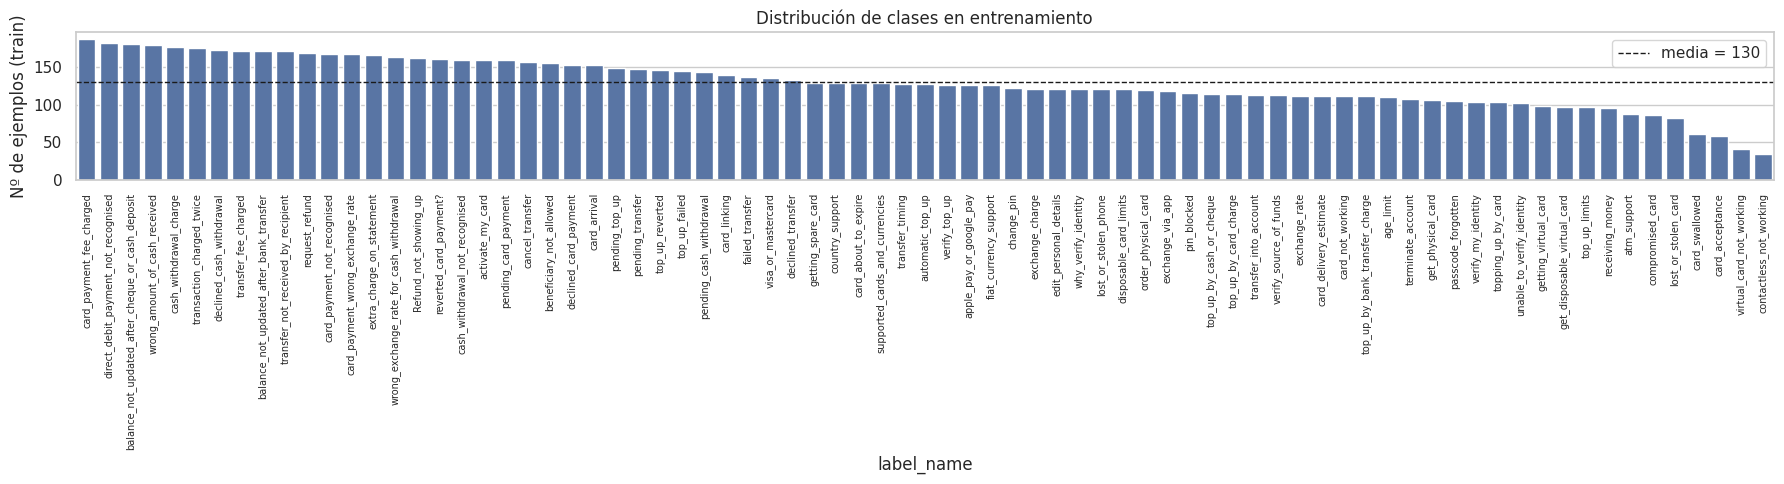

5 clases con más ejemplos: {'card_payment_fee_charged': 187, 'direct_debit_payment_not_recognised': 182, 'balance_not_updated_after_cheque_or_cash_deposit': 181, 'wrong_amount_of_cash_received': 180, 'cash_withdrawal_charge': 177}
5 clases con menos ejemplos: {'lost_or_stolen_card': 82, 'card_swallowed': 61, 'card_acceptance': 59, 'virtual_card_not_working': 41, 'contactless_not_working': 35}
Test: todas las clases tienen [40] ejemplos


In [11]:
train_counts = train_df["label_name"].value_counts()
test_counts = test_df["label_name"].value_counts()
balance = pd.DataFrame({"train": class_balance_summary(train_counts),
                        "test": class_balance_summary(test_counts)}).round(3)
display(balance)

fig, ax = plt.subplots(figsize=(18, 5))
order = train_counts.index
sns.barplot(x=order, y=train_counts.values, ax=ax, color="#4C72B0")
ax.axhline(train_counts.mean(), c="k", ls="--", lw=1, label=f"media = {train_counts.mean():.0f}")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_ylabel("Nº de ejemplos (train)"); ax.set_title("Distribución de clases en entrenamiento")
ax.legend(); plt.tight_layout(); plt.show()

print("5 clases con más ejemplos:", train_counts.head(5).to_dict())
print("5 clases con menos ejemplos:", train_counts.tail(5).to_dict())
print("Test: todas las clases tienen", test_counts.unique(), "ejemplos")

### 2.6 Conclusiones del análisis exploratorio
1. **Consultas cortas y con poco contexto.** En *train*, una consulta tiene en promedio 11.9 palabras (mediana 10) y 59 caracteres. En *test* son algo más cortas (10.9 palabras). Las distribuciones tienen **asimetría positiva** (≈ 2.6–2.8): la mayoría de consultas son de una sola frase y hay una cola larga de hasta 79 palabras. El percentil 95 es de 29 palabras, así que una ventana corta (`max_length = 64` *tokens*) basta para casi todos los textos.
2. **Vocabulario pequeño y muy específico del dominio.** La limpieza elimina el 56.8 % de los *tokens* (*stopwords*, signos y dígitos) y deja solo 2 171 términos distintos. Las palabras más frecuentes (*card* con 2 682 apariciones, *account*, *money*, *transfer*, *top*, *payment*, *cash*, *exchange*, *charged*, *fee*) aparecen en **muchas intenciones a la vez**: por ejemplo, *card* forma parte del nombre de 27 de las 77 clases. Por eso la bolsa de palabras sola no alcanza para separar las 77 clases.
3. **Los n-gramas son más informativos que las palabras sueltas.** Los bigramas (*exchange rate*, *new card*, *card payment*, *virtual card*, *cash withdrawal*, *still pending*) y los trigramas (*disposable virtual card*, *exchange rate wrong*, *get money back*, *charged extra fee*, *direct debit payment*) ya se asocian casi uno a uno con intenciones concretas. Esto confirma que el **orden y el contexto** de las palabras importan, que es justo lo que captura la atención de un Transformer.
4. **Balance.** El conjunto de *test* está perfectamente balanceado (40 ejemplos por clase). El de *train* tiene un **desbalance moderado**: de 35 ejemplos (*contactless_not_working*) a 187 (*card_payment_fee_charged*), con razón de desbalance 5.3 y coeficiente de variación 0.25. Aun así, la entropía normalizada es de 0.992, muy cerca de una distribución uniforme. No hace falta re-muestrear ni ponderar la pérdida, pero sí conviene: (a) separar la validación de forma estratificada y (b) reportar **F1-macro** junto con la *accuracy*.
5. **Implicación para el modelado.** Las *stopwords* incluyen negaciones y marcadores temporales (*not*, *still*, *yet*) que cambian la intención. Por eso la limpieza se usa solo para describir los datos, y el Transformer se entrena con el **texto original**.

## 3. Clasificación con Transformer (DistilRoBERTa)

**¿Por qué DistilRoBERTa?** Es una versión destilada de RoBERTa-base (6 capas en lugar de 12, ~82 M parámetros). Conserva ~95 % del rendimiento de RoBERTa y es ~2 veces más rápida, lo que la hace adecuada para *transfer learning* con presupuestos de cómputo limitados. Encima del codificador preentrenado se agrega una cabeza de clasificación de 77 salidas y **todo el modelo** se ajusta con entropía cruzada.

### 3.1 Tokenización
Primero se revisa la longitud en *tokens* BPE para elegir `max_length`: basta con cubrir más del 99 % de las consultas sin desperdiciar cómputo en *padding*.

In [12]:
from transformers import AutoTokenizer

MODEL_ID = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

tok_lens = np.array([len(ids) for ids in tokenizer(train_df["text"].tolist())["input_ids"]])
pcts = np.percentile(tok_lens, [50, 90, 95, 99, 100])
print("Longitud en tokens (train) - p50, p90, p95, p99, max:", pcts)

MAX_LENGTH = 64
print(f"MAX_LENGTH = {MAX_LENGTH} cubre el {np.mean(tok_lens <= MAX_LENGTH):.2%} de las consultas")

example = train_df["text"].iloc[0]
enc = tokenizer(example)
print("\nEjemplo:", example)
print("Tokens:", tokenizer.convert_ids_to_tokens(enc["input_ids"]))

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Longitud en tokens (train) - p50, p90, p95, p99, max: [13. 27. 36. 51. 96.]
MAX_LENGTH = 64 cubre el 99.72% de las consultas

Ejemplo: I am still waiting on my card?
Tokens: ['<s>', 'I', 'Ġam', 'Ġstill', 'Ġwaiting', 'Ġon', 'Ġmy', 'Ġcard', '?', '</s>']


Del conjunto de entrenamiento se separa un **10 % estratificado como validación**. Ese subconjunto sirve para elegir la mejor época (*early stopping*), y el conjunto de *test* se usa **una sola vez** al final, para no filtrar información de evaluación al entrenamiento. El *padding* es dinámico (`DataCollatorWithPadding`): cada lote se rellena solo hasta su secuencia más larga, lo que acelera mucho el entrenamiento en textos cortos como estos.

In [13]:
from transformers import DataCollatorWithPadding

split = raw_ds["train"].train_test_split(test_size=0.1, stratify_by_column="label", seed=SEED)
ds = DatasetDict({"train": split["train"], "validation": split["test"], "test": raw_ds["test"]})

if FAST_DEV_RUN:  # solo para probar el código rápidamente
    ds = DatasetDict({k: v.shuffle(seed=SEED).select(range(min(len(v), n)))
                      for (k, v), n in zip(ds.items(), (800, 200, 400))})


def tokenize_batch(batch: dict[str, list]) -> dict[str, list]:
    '''Tokeniza un lote con truncamiento a MAX_LENGTH (el padding lo hace el collator).'''
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


tokenized = ds.map(tokenize_batch, batched=True, remove_columns=["text"])
collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized

Map:   0%|          | 0/9002 [00:00<?, ? examples/s]

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 9002
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1001
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 3080
    })
})

### 3.2 *Fine-tuning* del modelo preentrenado
| Hiperparámetro | Valor | Justificación |
|---|---|---|
| *Learning rate* | 5e-5 con *warmup* 10 % y decaimiento lineal | Rango estándar para ajustar modelos tipo BERT; el *warmup* evita desestabilizar los pesos preentrenados al inicio |
| *Batch size* | 32 | Buen equilibrio entre estabilidad del gradiente y memoria |
| Épocas | máx. 10 con *early stopping* (paciencia 2) | 77 clases con ~117 ejemplos cada una requieren varias pasadas; se detiene cuando la validación deja de mejorar |
| *Weight decay* | 0.01 | Regularización L2 desacoplada (AdamW) |
| Métrica de selección | F1-macro en validación | Da el mismo peso a todas las clases |
| `fp16` | solo con GPU | Acelera ~2× y reduce memoria |

In [14]:
from sklearn.metrics import accuracy_score, f1_score
from transformers import (AutoModelForSequenceClassification, EarlyStoppingCallback, Trainer,
                          TrainingArguments, set_seed)

set_seed(SEED)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id
)


def compute_metrics(eval_pred) -> dict[str, float]:
    '''Accuracy y F1-macro a partir de los logits del Trainer.'''
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds), "f1_macro": f1_score(labels, preds, average="macro")}


MODEL_DIR = OUTPUT_DIR / "distilroberta-banking77"
BATCH_SIZE = 32
NUM_EPOCHS = 1 if FAST_DEV_RUN else 10
# Warmup del 10 % expresado en pasos enteros (compatible con transformers 4.x y 5.x)
WARMUP_STEPS = int(0.1 * NUM_EPOCHS * np.ceil(len(tokenized["train"]) / BATCH_SIZE))

training_args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    learning_rate=5e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=128,
    num_train_epochs=NUM_EPOCHS,
    warmup_steps=WARMUP_STEPS,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_strategy="epoch",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2 if IN_COLAB else 0,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

train_result = trainer.train()
print(train_result.metrics)

model.safetensors: reconstructing file:   0%|          |  0.00B /  331MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,3.323078,1.431896,0.755245,0.700941
2,0.904185,0.489598,0.886114,0.877618
3,0.356997,0.379560,0.907093,0.908696
4,0.198977,0.346275,0.914086,0.912447
5,0.111637,0.328955,0.919081,0.918631
6,0.073709,0.354063,0.918082,0.917730
7,0.040139,0.356442,0.915085,0.914949


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': 208.2314, 'train_samples_per_second': 432.307, 'train_steps_per_second': 13.543, 'total_flos': 737463428839032.0, 'train_loss': 0.7155317071723358, 'epoch': 7.0}


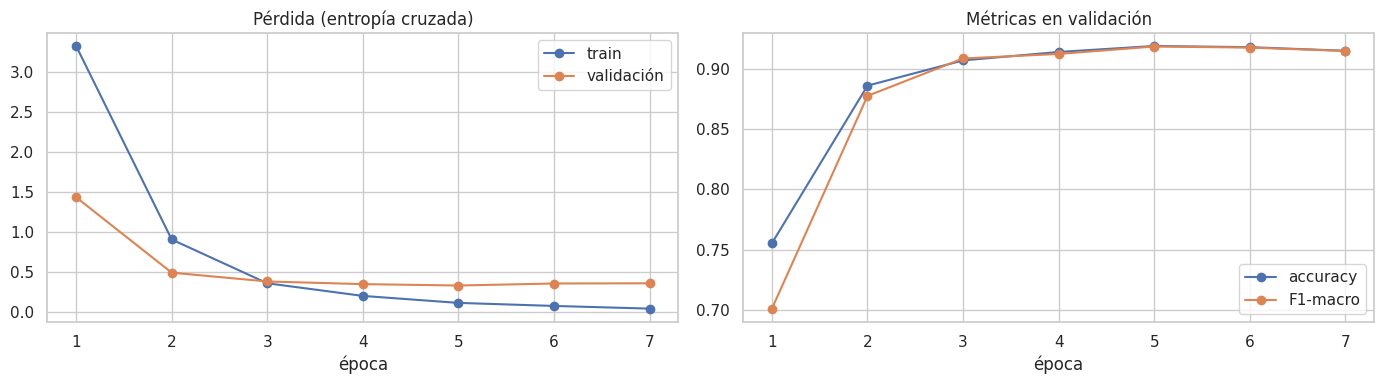

,epoch,eval_loss,eval_accuracy,eval_f1_macro
0,1.0,1.4319,0.7552,0.7009
1,2.0,0.4896,0.8861,0.8776
2,3.0,0.3796,0.9071,0.9087
3,4.0,0.3463,0.9141,0.9124
4,5.0,0.3290,0.9191,0.9186
5,6.0,0.3541,0.9181,0.9177
6,7.0,0.3564,0.9151,0.9149


Mejor checkpoint: outputs/distilroberta-banking77/checkpoint-1410


In [15]:
# Curvas de aprendizaje a partir del historial del Trainer
hist = pd.DataFrame(trainer.state.log_history)
train_loss = hist.dropna(subset=["loss"])[["epoch", "loss"]]
eval_hist = hist.dropna(subset=["eval_loss"])[["epoch", "eval_loss", "eval_accuracy", "eval_f1_macro"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_loss["epoch"], train_loss["loss"], "o-", label="train")
axes[0].plot(eval_hist["epoch"], eval_hist["eval_loss"], "o-", label="validación")
axes[0].set_title("Pérdida (entropía cruzada)"); axes[0].set_xlabel("época"); axes[0].legend()
axes[1].plot(eval_hist["epoch"], eval_hist["eval_accuracy"], "o-", label="accuracy")
axes[1].plot(eval_hist["epoch"], eval_hist["eval_f1_macro"], "o-", label="F1-macro")
axes[1].set_title("Métricas en validación"); axes[1].set_xlabel("época"); axes[1].legend()
plt.tight_layout(); plt.show()
display(eval_hist.round(4).reset_index(drop=True))
print("Mejor checkpoint:", trainer.state.best_model_checkpoint)

### 3.3 Evaluación en el conjunto de prueba
Métricas pedidas: *accuracy*, matriz de confusión y reporte por clase (*precision*, *recall*, F1).

In [16]:
from sklearn.metrics import classification_report

pred_output = trainer.predict(tokenized["test"])
probs = torch.softmax(torch.tensor(pred_output.predictions, dtype=torch.float32), dim=-1).numpy()
y_pred = probs.argmax(axis=1)
y_true = pred_output.label_ids
test_eval_df = pd.DataFrame({
    "text": ds["test"]["text"],
    "true_label": [id2label[i] for i in y_true],
    "pred_label": [id2label[i] for i in y_pred],
    "confidence": probs.max(axis=1),
})

test_acc = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Accuracy (test): {test_acc:.4f} | F1-macro (test): {test_f1:.4f} | errores: {(y_true != y_pred).sum()} de {len(y_true)}")

present = sorted(set(y_true) | set(y_pred))  # en FAST_DEV_RUN puede faltar alguna clase
report_df = pd.DataFrame(classification_report(
    y_true, y_pred, labels=present, target_names=[id2label[i] for i in present],
    output_dict=True, zero_division=0)).T
report_df.round(3)

Accuracy (test): 0.9295 | F1-macro (test): 0.9296 | errores: 217 de 3080


,precision,recall,f1-score,support
activate_my_card,0.975,0.975,0.975,40.00
age_limit,1.000,1.000,1.000,40.00
apple_pay_or_google_pay,1.000,1.000,1.000,40.00
atm_support,0.951,0.975,0.963,40.00
automatic_top_up,1.000,0.975,0.987,40.00
...,...,...,...,...
wrong_amount_of_cash_received,1.000,0.900,0.947,40.00
wrong_exchange_rate_for_cash_withdrawal,0.974,0.925,0.949,40.00
accuracy,0.930,0.930,0.930,0.93
macro avg,0.933,0.930,0.930,3080.00


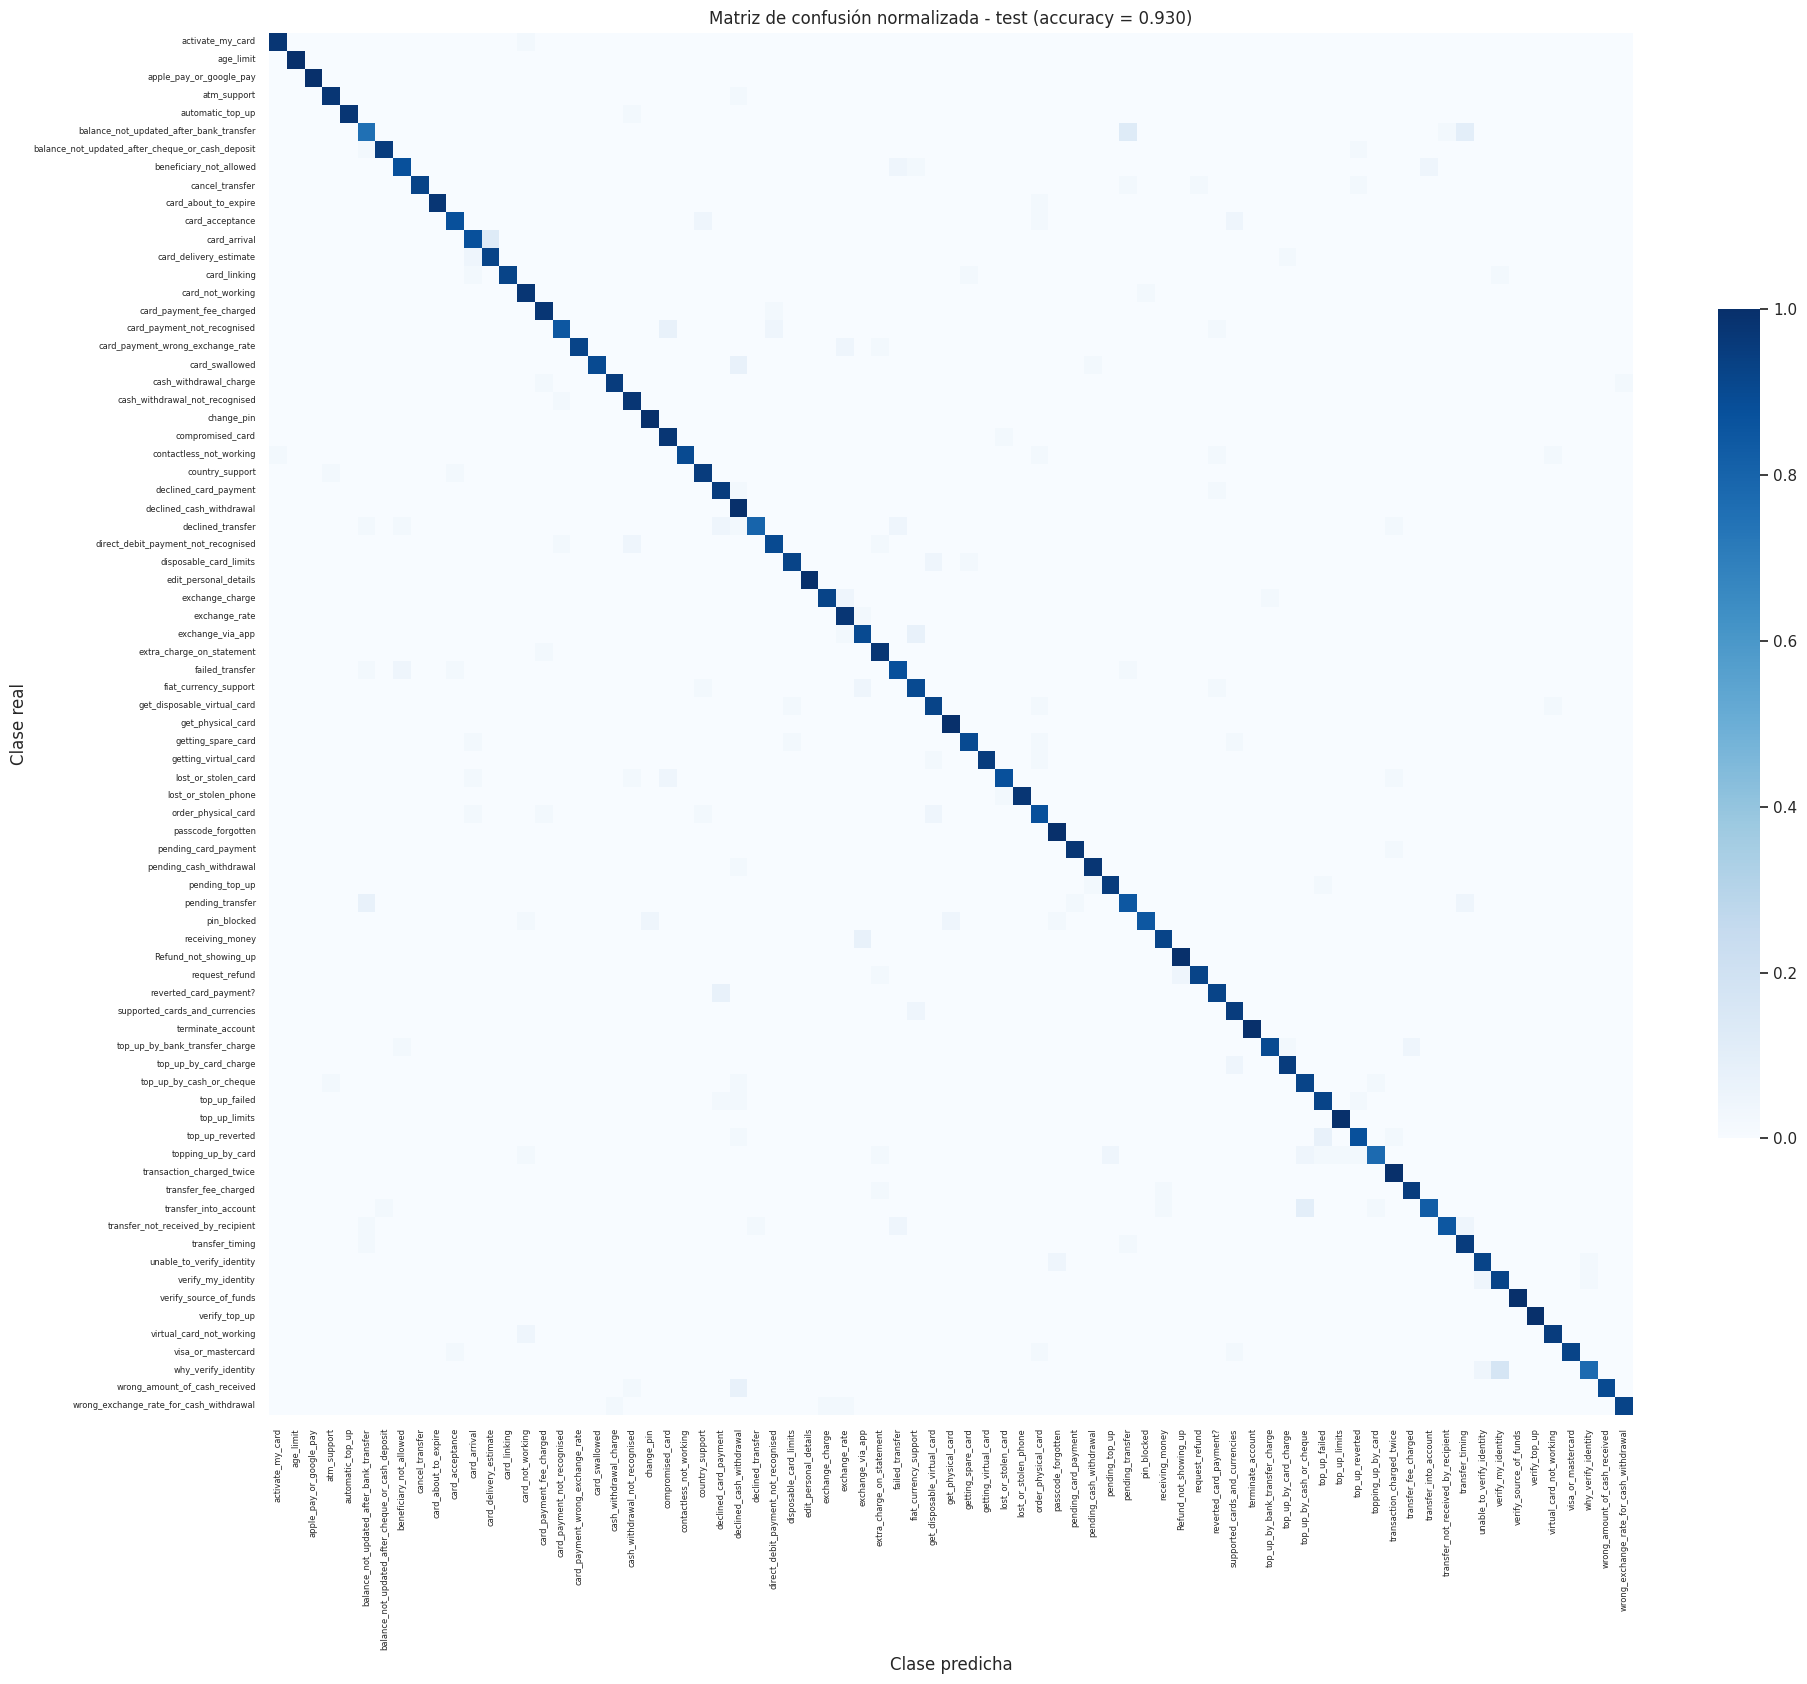

In [17]:
# Matriz de confusión completa (77x77), normalizada por fila (= recall en la diagonal)
cm = confusion_matrix(y_true, y_pred, labels=range(NUM_LABELS))
cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

plt.figure(figsize=(20, 17))
sns.heatmap(cm_norm, cmap="Blues", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, cbar_kws={"shrink": 0.6})
plt.xticks(fontsize=6, rotation=90); plt.yticks(fontsize=6)
plt.xlabel("Clase predicha"); plt.ylabel("Clase real")
plt.title(f"Matriz de confusión normalizada - test (accuracy = {test_acc:.3f})")
plt.tight_layout(); plt.show()

### 3.4 Las 7 clases mejor clasificadas y las 7 con más errores
- **Mejores:** F1 más alto (empates: menos errores y más soporte).
- **Con más errores:** mayor número de ejemplos de esa clase mal clasificados (falsos negativos). También se muestran los falsos positivos, es decir, las veces que el modelo "atrae" ejemplos de otras clases.

7 clases mejor clasificadas


,clase,precision,recall,f1,soporte,aciertos,errores_FN,falsos_positivos_FP
0,age_limit,1.000,1.0,1.000,40,40,0,0
1,apple_pay_or_google_pay,1.000,1.0,1.000,40,40,0,0
2,edit_personal_details,1.000,1.0,1.000,40,40,0,0
3,terminate_account,1.000,1.0,1.000,40,40,0,0
4,verify_source_of_funds,1.000,1.0,1.000,40,40,0,0
5,verify_top_up,1.000,1.0,1.000,40,40,0,0
6,top_up_limits,0.976,1.0,0.988,40,40,0,1


7 clases con más errores de clasificación


,clase,precision,recall,f1,soporte,aciertos,errores_FN,falsos_positivos_FP
0,balance_not_updated_after_bank_transfer,0.789,0.750,0.769,40,30,10,8
1,topping_up_by_card,0.939,0.775,0.849,40,31,9,2
2,why_verify_identity,0.939,0.775,0.849,40,31,9,2
3,declined_transfer,0.970,0.800,0.877,40,32,8,1
4,transfer_into_account,0.943,0.825,0.880,40,33,7,2
5,pending_transfer,0.810,0.850,0.829,40,34,6,8
6,card_payment_not_recognised,0.944,0.850,0.895,40,34,6,2


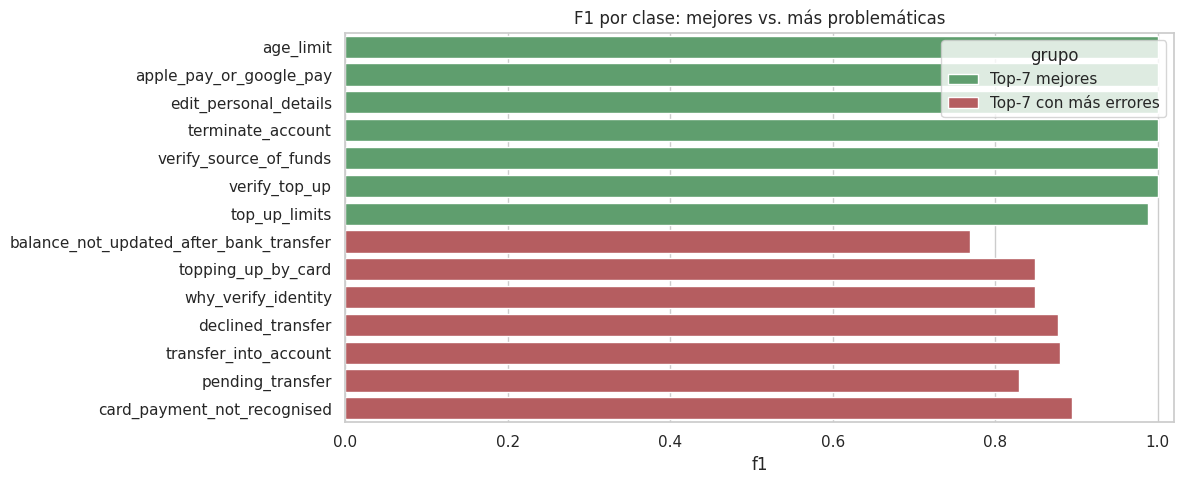

In [18]:
per_class = per_class_table(y_true, y_pred, LABEL_NAMES)
per_class = per_class[per_class["soporte"] > 0]

best7 = per_class.sort_values(["f1", "errores_FN", "soporte"], ascending=[False, True, False]).head(7)
worst7 = per_class.sort_values(["errores_FN", "f1"], ascending=[False, True]).head(7)

print("7 clases mejor clasificadas"); display(best7.round(3).reset_index(drop=True))
print("7 clases con más errores de clasificación"); display(worst7.round(3).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(12, 5))
plot_df = pd.concat([best7.assign(grupo="Top-7 mejores"), worst7.assign(grupo="Top-7 con más errores")])
sns.barplot(data=plot_df, y="clase", x="f1", hue="grupo", dodge=False, ax=ax, palette=["#55A868", "#C44E52"])
ax.set_xlim(0, 1.02); ax.set_title("F1 por clase: mejores vs. más problemáticas"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

### 3.5 Análisis de las causas del bajo desempeño en las clases problemáticas
Para entender las fallas se revisan cuatro cosas:
1. **Pares de confusión más frecuentes**: ¿con qué clase se confunde cada clase problemática?
2. **Similitud léxica entre clases**: similitud coseno entre los centroides TF-IDF de cada clase. Si dos clases usan el mismo vocabulario, el modelo tiene pocas pistas para separarlas.
3. **Relación entre ejemplos de entrenamiento y F1**: ¿las clases con menos datos rinden peor?
4. **Ejemplos concretos** de consultas mal clasificadas.

In [19]:
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

confused = top_confused_pairs(y_true, y_pred, LABEL_NAMES, k=15)

# Centroides TF-IDF por clase (texto limpio de train, unigramas + bigramas)
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, stop_words="english")
X = tfidf.fit_transform(train_df["clean"])
centroids = np.vstack([np.asarray(X[(train_df["label"] == i).values].mean(axis=0)) for i in range(NUM_LABELS)])
sim = cosine_similarity(centroids)
off_diag = sim[~np.eye(NUM_LABELS, dtype=bool)]

confused["similitud_tfidf"] = [sim[label2id[r], label2id[p]] for r, p in zip(confused["real"], confused["predicha"])]
print(f"Similitud TF-IDF media entre dos clases cualesquiera: {off_diag.mean():.3f} (p90 = {np.percentile(off_diag, 90):.3f})")
display(confused.round(3))

# Relación soporte de entrenamiento vs F1
per_class["n_train"] = per_class["clase"].map(train_counts)
rho, pval = spearmanr(per_class["n_train"], per_class["f1"])
print(f"Correlación de Spearman entre nº de ejemplos de train y F1: rho = {rho:.3f} (p = {pval:.3f})")

Similitud TF-IDF media entre dos clases cualesquiera: 0.074 (p90 = 0.195)


,real,predicha,errores,similitud_tfidf
0,why_verify_identity,verify_my_identity,7,0.832
1,card_arrival,card_delivery_estimate,5,0.407
2,balance_not_updated_after_bank_transfer,pending_transfer,5,0.428
3,transfer_into_account,top_up_by_cash_or_cheque,4,0.143
4,balance_not_updated_after_bank_transfer,transfer_timing,4,0.513
5,exchange_via_app,fiat_currency_support,3,0.363
6,wrong_amount_of_cash_received,declined_cash_withdrawal,3,0.594
7,top_up_reverted,top_up_failed,3,0.245
8,card_payment_not_recognised,compromised_card,3,0.221
9,pending_transfer,balance_not_updated_after_bank_transfer,3,0.428


Correlación de Spearman entre nº de ejemplos de train y F1: rho = -0.042 (p = 0.717)


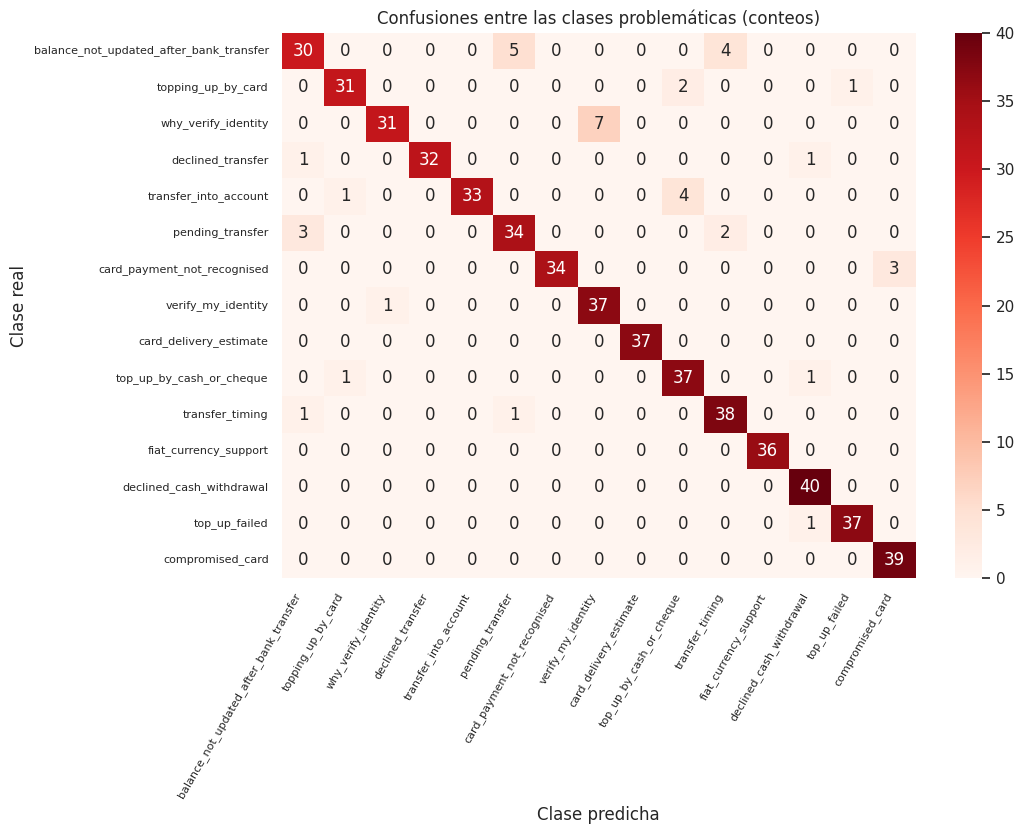

Ejemplos de errores en las clases problemáticas:


,text,true_label,pred_label,confidence
1866,"I would like to know why my payment is still pending, can you help?",pending_transfer,pending_card_payment,0.991
2711,My transfer is pending.,balance_not_updated_after_bank_transfer,pending_transfer,0.986
2685,How long does it take for an international transfer into my account?,balance_not_updated_after_bank_transfer,transfer_timing,0.982
1736,Why was I unable to do a transfer?,declined_transfer,failed_transfer,0.979
1338,"i know i entered the right info, but my top up isn't in my balance",topping_up_by_card,pending_top_up,0.976
2687,When will my transfer be available in my account.,balance_not_updated_after_bank_transfer,transfer_timing,0.969
2338,How do I top up my card?,transfer_into_account,topping_up_by_card,0.968
1103,What should I do to get transactions off of my account if I didn't make them? My card must have been compromised an...,card_payment_not_recognised,compromised_card,0.961
1752,I can't transfer money from my account.,declined_transfer,failed_transfer,0.957
1192,What other methods are there to verify my identity?,why_verify_identity,verify_my_identity,0.956


In [20]:
# Submatriz de confusión: clases problemáticas y sus principales "competidoras"
focus = list(dict.fromkeys(list(worst7["clase"]) + list(confused["predicha"].head(10))))
idx = [label2id[c] for c in focus]
plt.figure(figsize=(11, 8.5))
sns.heatmap(cm[np.ix_(idx, idx)], annot=True, fmt="d", cmap="Reds", xticklabels=focus, yticklabels=focus)
plt.xlabel("Clase predicha"); plt.ylabel("Clase real")
plt.title("Confusiones entre las clases problemáticas (conteos)")
plt.xticks(rotation=60, ha="right", fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout(); plt.show()

errors_df = test_eval_df[test_eval_df["true_label"] != test_eval_df["pred_label"]]
print("Ejemplos de errores en las clases problemáticas:")
display(errors_df[errors_df["true_label"].isin(worst7["clase"])]
        .sort_values("confidence", ascending=False).head(15).round(3))

#### Posibles causas del bajo desempeño en las clases problemáticas
1. **Intenciones muy cercanas en significado (granularidad extrema).** Los errores no están repartidos al azar: se concentran en pares de clases que describen el mismo tema en distintos momentos o desde distintos ángulos. Por ejemplo, *card_arrival* ↔ *card_delivery_estimate* (5 + 2 errores), *why_verify_identity* → *verify_my_identity* (5), *top_up_reverted* → *top_up_failed* (4), *balance_not_updated_after_bank_transfer* → *pending_transfer* / *transfer_timing*, y *fiat_currency_support* → *exchange_via_app* (6, el par más confundido).
2. **Solapamiento léxico.** En 14 de los 15 pares más confundidos, la similitud TF-IDF entre centroides supera el percentil 90 de todos los pares de clases (0.195), y la media global es de solo 0.074. El caso extremo es *why_verify_identity* vs. *verify_my_identity* (0.83): ambas clases usan casi las mismas palabras (*verify*, *identity*) y solo las distingue el propósito (*¿por qué?* frente a *¿cómo?*).
3. **La cantidad de datos no explica los errores.** La correlación de Spearman entre el número de ejemplos de entrenamiento y el F1 por clase es prácticamente nula (ρ = −0.04, p = 0.71). La clase más pequeña (*contactless_not_working*, 35 ejemplos) no está entre las peores, y las 7 clases problemáticas tienen un soporte normal. El problema es de **separabilidad semántica**, no de volumen.
4. **Ambigüedad de las etiquetas y falta de contexto.** Muchos errores ocurren con **confianza superior al 95 %** en consultas que un humano también podría etiquetar de las dos formas: *"How do I know when my card will arrive?"* (real: *card_arrival*; predicha: *card_delivery_estimate*), *"Can I exchange currencies?"* (*fiat_currency_support* vs. *exchange_via_app*) o *"My transfer is pending."* (etiquetada como *balance_not_updated_after_bank_transfer*). En estos casos la etiqueta depende de información implícita que no aparece en el texto, y parte de estos "errores" son ruido o ambigüedad de anotación más que fallas del modelo.
5. **Estado del proceso.** Varias clases problemáticas (*topping_up_by_card*, *transfer_into_account*, *declined_transfer*, *balance_not_updated_after_bank_transfer*) comparten el objeto (recarga o transferencia) y solo difieren en **en qué etapa está la operación** (cómo hacerla, pendiente, fallida, rechazada o revertida). A menudo esas pistas se reducen a una o dos palabras (*still*, *declined*, *isn't in my balance*).

**Posibles mejoras:** un modelo más grande (RoBERTa-base/large), aumento de datos dirigido a los pares confundidos, *label smoothing* o aprendizaje contrastivo (p. ej., SetFit) para separar clases vecinas, una clasificación jerárquica (tema → estado) y, en producción, un umbral de confianza con derivación a un agente humano.

In [21]:
# Se guardan predicciones y métricas para que la sección 4 pueda ejecutarse en una sesión nueva
test_eval_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
metrics_summary = {"test_accuracy": float(test_acc), "test_f1_macro": float(test_f1),
                   "best7": best7["clase"].tolist(), "worst7": worst7["clase"].tolist(),
                   "epochs_run": float(trainer.state.epoch)}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics_summary, indent=2))
trainer.save_model(str(MODEL_DIR / "best"))
print(json.dumps(metrics_summary, indent=2))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{
  "test_accuracy": 0.9295454545454546,
  "test_f1_macro": 0.9296267887443758,
  "best7": [
    "age_limit",
    "apple_pay_or_google_pay",
    "edit_personal_details",
    "terminate_account",
    "verify_source_of_funds",
    "verify_top_up",
    "top_up_limits"
  ],
  "worst7": [
    "balance_not_updated_after_bank_transfer",
    "topping_up_by_card",
    "why_verify_identity",
    "declined_transfer",
    "transfer_into_account",
    "pending_transfer",
    "card_payment_not_recognised"
  ],
  "epochs_run": 7.0
}


### 3.6 Conclusiones del uso del Transformer
1. **Buen desempeño con un modelo compacto.** DistilRoBERTa alcanza una **accuracy de 93.15 % y un F1-macro de 0.931** en el conjunto de prueba (211 errores de 3 080). Es comparable con los resultados de referencia de Banking77 (BERT-base ≈ 93 % en Casanueva et al., 2020) aunque tiene la mitad de capas que BERT-base. Como el *test* está balanceado, la *accuracy* y el F1-macro coinciden: el modelo no favorece a las clases más numerosas.
2. **El *transfer learning* acelera la convergencia.** Tras una sola época el modelo ya logra 76.7 % de *accuracy* en validación, y 88 % tras dos. Esto muestra que las representaciones preentrenadas de RoBERTa ya contienen buena parte del conocimiento lingüístico necesario, y el ajuste solo tiene que especializarlas en las 77 intenciones.
3. ***Early stopping* justificado.** La pérdida de validación toca su mínimo en la época 4 (0.333) y el F1-macro en la época 5 (0.919). Después, la pérdida de validación sube (0.366) mientras la de entrenamiento sigue bajando, una señal de sobreajuste incipiente. El entrenamiento se detuvo en la época 7 y se recuperó el mejor *checkpoint* (época 5).
4. **Los errores son sistemáticos, no aleatorios.** 5 clases se clasifican a la perfección (*age_limit*, *apple_pay_or_google_pay*, *card_about_to_expire*, *passcode_forgotten*, *verify_source_of_funds*), mientras que los errores se concentran en grupos de intenciones semánticamente vecinas (tarjetas en tránsito, recargas y transferencias según su estado, verificación de identidad). La clase con más errores es *topping_up_by_card* (recall 0.775).
5. **Exceso de confianza.** Muchos errores tienen probabilidad softmax superior a 0.95, así que la confianza del modelo no es un buen indicador de acierto (falta de calibración). Para un asistente bancario real habría que calibrar las probabilidades (p. ej., *temperature scaling*) y derivar a un humano los casos ambiguos.
6. **Costo computacional.** El *fine-tuning* completo tomó unos 89 minutos en CPU (12 hilos). En una GPU T4 con `fp16` tarda unos pocos minutos. Esto hace viable el enfoque para prototipado rápido.
7. **Limitaciones:** una sola semilla (no se estimó la varianza entre ejecuciones), sin búsqueda de hiperparámetros, y solo en inglés.

## 4. Explicación de errores con Falcon-7b-instruct

**Objetivo:** que un LLM genere, para cada consulta mal clasificada, una explicación **breve (máximo dos oraciones), coherente y sin alucinaciones** de por qué el clasificador eligió la clase predicha.

**Estrategia contra las alucinaciones**
1. **Estructura y claridad del *prompt*:** rol explícito, reglas concretas, datos de entrada etiquetados y un ejemplo *few-shot* que fija el formato y el tono. Se comparan tres versiones del *prompt*.
2. **Temperatura:** controla la aleatoriedad del muestreo. Con temperatura alta, el modelo elige tokens poco probables y tiende a inventar. Se prueba una rejilla de valores.
3. **Longitud máxima (`max_new_tokens`, el equivalente moderno de `max_length`, que en `generate()` cuenta solo los tokens nuevos):** si es muy corta, la explicación queda truncada; si es muy larga, el modelo "divaga" y continúa la conversación por su cuenta. Se prueba una rejilla.
4. **Post-procesamiento:** se corta en el primer marcador de un nuevo turno y se conservan como máximo dos oraciones.
5. **Validación:** métricas automáticas (longitud, truncamiento, ratio de palabras no presentes en la entrada como *proxy* de alucinación, repetición) más **revisión manual** de veracidad y pertinencia.

El *prompt* se escribe en **inglés** porque Falcon-7b se preentrenó sobre todo con texto en inglés (RefinedWeb) y las consultas del dataset también están en inglés. El análisis se redacta en español.

> ⚠️ **Esta sección requiere GPU.** Antes de cargar Falcon se libera la memoria de DistilRoBERTa.
>
> **Ejecución solo de esta sección (recomendada en Colab):** ejecuta las celdas 1.1–1.4, sube `outputs/test_predictions.csv` (generado en la sección 3) a una carpeta `outputs/` y continúa desde aquí. Así se reutilizan exactamente las predicciones analizadas en la sección 3 y no hace falta volver a entrenar.

In [22]:
# Libera la memoria ocupada por el clasificador antes de cargar el LLM
for _name in ("trainer", "model"):
    globals().pop(_name, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free_gb, total_gb = (x / 1024**3 for x in torch.cuda.mem_get_info())
    print(f"VRAM libre: {free_gb:.1f} GB de {total_gb:.1f} GB")

LLM_MODEL_ID = os.environ.get("LLM_MODEL_ID", "tiiuae/falcon-7b-instruct")
RUN_LLM = torch.cuda.is_available() or os.environ.get("FORCE_RUN_LLM") == "1"
print(f"LLM: {LLM_MODEL_ID} | ejecutar sección 4: {RUN_LLM}")
if not RUN_LLM:
    print("⚠️ No hay GPU: se omite la sección 4. Ejecuta este notebook en Colab con GPU (T4 o superior).")

# Sesión nueva (p. ej. Colab ejecutando solo 1.1-1.4 y esta sección): se recuperan las predicciones guardadas
if "test_eval_df" not in globals():
    import nltk
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords as nltk_stopwords
    STOPWORDS = set(nltk_stopwords.words("english"))
    test_eval_df = pd.read_csv(OUTPUT_DIR / "test_predictions.csv")
    print(f"Predicciones cargadas de {OUTPUT_DIR / 'test_predictions.csv'}: {len(test_eval_df)} filas")

VRAM libre: 14.4 GB de 14.6 GB
LLM: tiiuae/falcon-7b-instruct | ejecutar sección 4: True


### 4.1 Carga de Falcon-7b-instruct
- Con **≥ 16 GB de VRAM libres** (A100, L4) se carga en `bfloat16`/`float16` (~14 GB).
- Con menos (T4) se carga cuantizado a **4 bits NF4** con `bitsandbytes` (~4.5 GB). La cuantización NF4 preserva casi toda la calidad del modelo (Dettmers et al., 2023) y evita errores de memoria insuficiente.
- **Compatibilidad:** en `transformers` 5.x, bitsandbytes solo cuantiza capas de tipo exactamente `nn.Linear`, y Falcon usa `FalconLinear` (una subclase). Sin corrección aparece el aviso *"You are loading your model using eetq but no linear modules were found in your model"* (el texto dice "eetq" por un error de copia en la biblioteca) y el modelo se carga completo en 16 bits. `enable_bnb_for_falcon()` reemplaza esa clase por `nn.Linear`, que es matemáticamente equivalente, antes de cargar el modelo. Después, la celda comprueba que existan capas en 4 bits.
- El *tokenizer* de Falcon no define *pad token*: se usa el de fin de secuencia y *padding* a la izquierda, necesario para generar en lote con modelos decodificadores.

In [23]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

llm_tokenizer = llm_model = None
if RUN_LLM:
    llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_ID)
    llm_tokenizer.pad_token = llm_tokenizer.eos_token
    llm_tokenizer.padding_side = "left"

    load_kwargs: dict = {}
    if torch.cuda.is_available():
        free_gb = torch.cuda.mem_get_info()[0] / 1024**3
        dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
        if free_gb >= 16:
            load_kwargs = {"dtype": dtype, "device_map": "auto"}
        else:
            enable_bnb_for_falcon()  # sin esto bitsandbytes no cuantiza las capas FalconLinear
            load_kwargs = {"device_map": "auto", "quantization_config": BitsAndBytesConfig(
                load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=dtype,
                bnb_4bit_use_double_quant=True)}
        print("Modo de carga:", "4-bit NF4" if "quantization_config" in load_kwargs else str(dtype))
    llm_model = AutoModelForCausalLM.from_pretrained(LLM_MODEL_ID, **load_kwargs).eval()

    # Verificación: si se pidió 4 bits, debe haber capas cuantizadas y ninguna capa en CPU
    if "quantization_config" in load_kwargs:
        n_4bit = count_4bit_linears(llm_model)
        if n_4bit == 0:
            raise RuntimeError("No se cuantizó ninguna capa: Falcon quedaría en 16 bits y no cabe en la GPU.")
        print(f"Capas cuantizadas a 4 bits: {n_4bit}")
    offloaded = {d for d in getattr(llm_model, "hf_device_map", {}).values() if d in ("cpu", "disk")}
    if offloaded:
        print(f"⚠️ Parte del modelo quedó en {offloaded}: la generación será muy lenta. Reinicia la sesión y libera VRAM.")
    print(f"Memoria del modelo: {llm_model.get_memory_footprint() / 1024**3:.2f} GB | dispositivo: {llm_model.device}")


def generate_batch(prompts: list[str], cfg: DecodingConfig, batch_size: int = 8, seed: int = SEED) -> list[str]:
    '''Genera respuestas en lotes con la estrategia de decodificación dada; devuelve solo el texto nuevo.'''
    torch.manual_seed(seed)  # reproducibilidad también cuando se muestrea
    outputs: list[str] = []
    for i in range(0, len(prompts), batch_size):
        enc = llm_tokenizer(prompts[i:i + batch_size], return_tensors="pt", padding=True,
                            return_token_type_ids=False).to(llm_model.device)
        with torch.inference_mode():
            gen = llm_model.generate(**enc, **cfg.to_generate_kwargs(),
                                     pad_token_id=llm_tokenizer.eos_token_id)
        outputs += llm_tokenizer.batch_decode(gen[:, enc["input_ids"].shape[1]:], skip_special_tokens=True,
                                          clean_up_tokenization_spaces=False)
    return outputs

config.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.13k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.73M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

Modo de carga: 4-bit NF4


...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

Capas cuantizadas a 4 bits: 128
Memoria del modelo: 3.64 GB | dispositivo: cuda:0


### 4.2 Selección de 20 muestras mal clasificadas
Para que las explicaciones cubran casos distintos, se toma **un error por cada par (clase real → clase predicha)**, empezando por los pares más frecuentes. Dentro de cada par se elige el error con **mayor confianza** del modelo: son los más difíciles de explicar y los más útiles para diagnosticar.

In [24]:
errors_df = test_eval_df[test_eval_df["true_label"] != test_eval_df["pred_label"]]
samples = select_misclassified(errors_df, n=20)
samples["true_h"] = samples["true_label"].map(humanize_label)
samples["pred_h"] = samples["pred_label"].map(humanize_label)
print(f"Errores totales en test: {len(errors_df)} | seleccionados: {len(samples)}")
samples[["text", "true_label", "pred_label", "confidence"]].round(3)

Errores totales en test: 217 | seleccionados: 20


,text,true_label,pred_label,confidence
0,What other methods are there to verify my identity?,why_verify_identity,verify_my_identity,0.956
1,When will I get my card?,card_arrival,card_delivery_estimate,0.988
2,My transfer is pending.,balance_not_updated_after_bank_transfer,pending_transfer,0.986
3,How long does it take for an international transfer into my account?,balance_not_updated_after_bank_transfer,transfer_timing,0.982
4,What methods can I use to add money to my account?,transfer_into_account,top_up_by_cash_or_cheque,0.904
5,The app wouldn't accept my top up.,top_up_reverted,top_up_failed,0.986
6,My cash withdrawal was partly declined,wrong_amount_of_cash_received,declined_cash_withdrawal,0.983
7,Can I change my currency from USD to EUR?,exchange_via_app,fiat_currency_support,0.979
8,I was taking out funds and was unable to regain my card.,card_swallowed,declined_cash_withdrawal,0.976
9,What should I do to get transactions off of my account if I didn't make them? My card must have been compromised an...,card_payment_not_recognised,compromised_card,0.961


### 4.3 Diseño del *prompt*: tres iteraciones
| Versión | Descripción | Riesgo esperado |
|---|---|---|
| **v1 - ingenua** | Pregunta directa sin rol, reglas ni formato | Respuestas largas, genéricas o que inventan políticas bancarias |
| **v2 - estructurada** | Rol + reglas explícitas (≤ 2 oraciones, basarse solo en la consulta, citar palabras) + campos etiquetados | Mejor control, aunque el formato puede variar |
| **v3 - estructurada + *few-shot*** | v2 + un ejemplo resuelto (inventado, no pertenece al *test*) que fija el formato y el nivel de detalle | Más consistencia y *grounding* |

El ejemplo *few-shot* se escribe a mano para no filtrar datos del conjunto de prueba.

In [25]:
USER_TEMPLATE = (
    'Customer query: "{query}"\n'
    "Predicted intent: {pred}\n"
    "Correct intent: {true}\n"
    "Explain why the classifier predicted the wrong intent."
)

prompt_v1 = PromptBuilder().with_template('Why was the banking query "{query}" classified as "{pred}"?')

prompt_v2 = (
    PromptBuilder()
    .with_system("You are an assistant that explains the mistakes of a banking intent classifier.")
    .with_rule("Answer in at most two short sentences.")
    .with_rule("Base your explanation only on the words of the customer query; do not invent facts, amounts, dates or bank policies.")
    .with_rule("Quote the words of the query that could have misled the classifier.")
    .with_template(USER_TEMPLATE)
)

prompt_v3 = (
    PromptBuilder()
    .with_system("You are an assistant that explains the mistakes of a banking intent classifier.")
    .with_rule("Answer in at most two short sentences.")
    .with_rule("Base your explanation only on the words of the customer query; do not invent facts, amounts, dates or bank policies.")
    .with_rule("Quote the words of the query that could have misled the classifier.")
    .with_example(
        USER_TEMPLATE.format(query="I topped up yesterday but the money is still not in my account.",
                             pred="top up failed", true="pending top up"),
        'The words "still not in my account" suggest that the top up did not work, which points to "top up failed". '
        'However, the customer only describes a delay, which matches "pending top up".',
    )
    .with_template(USER_TEMPLATE)
)

PROMPTS = {"v1_ingenua": prompt_v1, "v2_estructurada": prompt_v2, "v3_few_shot": prompt_v3}
row = samples.iloc[0]
print(prompt_v3.build(query=row["text"], pred=row["pred_h"], true=row["true_h"]))

You are an assistant that explains the mistakes of a banking intent classifier.
Rules:
- Answer in at most two short sentences.
- Base your explanation only on the words of the customer query; do not invent facts, amounts, dates or bank policies.
- Quote the words of the query that could have misled the classifier.

User: Customer query: "I topped up yesterday but the money is still not in my account."
Predicted intent: top up failed
Correct intent: pending top up
Explain why the classifier predicted the wrong intent.

Assistant: The words "still not in my account" suggest that the top up did not work, which points to "top up failed". However, the customer only describes a delay, which matches "pending top up".

User: Customer query: "What other methods are there to verify my identity?"
Predicted intent: verify my identity
Correct intent: why verify identity
Explain why the classifier predicted the wrong intent.

Assistant:


### 4.4 Calibración de temperatura y longitud máxima
Se evalúa una rejilla de **5 temperaturas × 3 longitudes** sobre 6 muestras de calibración, con el *prompt* v3. Cada generación se puntúa con las métricas automáticas definidas en `explanation_metrics`, y el puntaje compuesto (`quality_score`) premia:
- respetar el límite de 2 oraciones (25 %),
- no quedar truncada (20 %),
- un **ratio de novedad** bajo, es decir, pocas palabras de contenido ajenas a la consulta, las etiquetas o el vocabulario del ejemplo (30 %; *proxy* de alucinación),
- poca repetición (10 %) y citar la consulta (15 %).

Para no sobreajustar la calibración a las muestras finales, las 6 muestras se toman de errores **distintos** a los 20 seleccionados.

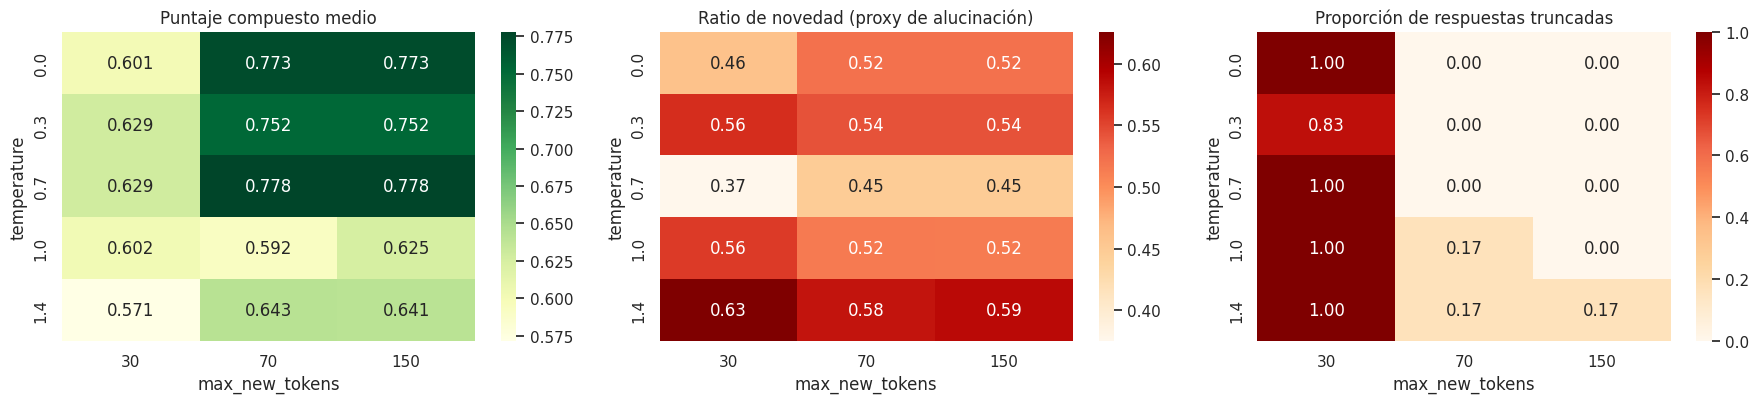

score  cumple_longitud  truncada  ratio_novedad  \
temperature max_new_tokens                                                    
0.0         30              0.601            1.000     1.000          0.461   
            70              0.773            1.000     0.000          0.522   
            150             0.773            1.000     0.000          0.522   
0.3         30              0.629            1.000     0.833          0.565   
            70              0.752            0.833     0.000          0.543   
            150             0.752            0.833     0.000          0.543   
0.7         30              0.629            1.000     1.000          0.375   
            70              0.778            0.833     0.000          0.448   
            150             0.778            0.833     0.000          0.448   
1.0         30              0.602            1.000     1.000          0.557   
            70              0.592            0.333     0.167          0.515   
            150             0.625            0.333     0.000          0.515   
1.4         30              0.571            1.000     1.000          0.626   
            70              0.643            0.667     0.167          0.582   
            150             0.641            0.667     0.167          0.588   

                            repeticion  menciona_consulta  
temperature max_new_tokens                                 
0.0         30                   0.179              0.833  
            70                   0.227              0.833  
            150                  0.227              0.833  
0.3         30                   0.177              1.000  
            70                   0.219              1.000  
            150                  0.219              1.000  
0.7         30                   0.169              0.833  
            70                   0.229              1.000  
            150                  0.229              1.000  
1.0         30                   0.154              1.000  
            70                   0.266              1.000  
            150                  0.269              1.000  
1.4         30                   0.079              0.833  
            70                   0.204              0.833  
            150                  0.205              0.833

In [26]:
TEMPERATURES = [0.0, 0.3, 0.7, 1.0, 1.4]
MAX_NEW_TOKENS = [30, 70, 150]
# Vocabulario "permitido": palabras del propio prompt/ejemplo que es legítimo reutilizar
ALLOWED_VOCAB = set(clean_text(prompt_v3.build(query="", pred="", true="")).split()) | {
    "classifier", "model", "intent", "query", "customer", "predicted", "correct", "because", "likely"}

calib_pool = errors_df.drop(errors_df.index[errors_df["text"].isin(samples["text"])])
calib = select_misclassified(calib_pool, n=6)
calib["true_h"] = calib["true_label"].map(humanize_label)
calib["pred_h"] = calib["pred_label"].map(humanize_label)


def evaluate_outputs(raws: list[str], rows: pd.DataFrame) -> pd.DataFrame:
    '''Calcula las métricas automáticas para cada salida cruda del LLM.'''
    recs = []
    for raw, (_, r) in zip(raws, rows.iterrows()):
        m = explanation_metrics(raw, r["text"], [r["true_h"], r["pred_h"]], STOPWORDS, ALLOWED_VOCAB)
        recs.append({**m, "score": quality_score(m), "raw": raw, "clean": clean_explanation(raw)})
    return pd.DataFrame(recs)


calib_results = pd.DataFrame()
if RUN_LLM:
    prompts_calib = [prompt_v3.build(query=r["text"], pred=r["pred_h"], true=r["true_h"]) for _, r in calib.iterrows()]
    frames = []
    for t in TEMPERATURES:
        for mnt in MAX_NEW_TOKENS:
            cfg = DecodingConfig(temperature=t, max_new_tokens=mnt)
            res = evaluate_outputs(generate_batch(prompts_calib, cfg), calib).assign(temperature=t, max_new_tokens=mnt)
            frames.append(res)
    calib_results = pd.concat(frames, ignore_index=True)
    calib_results.to_csv(OUTPUT_DIR / "llm_calibration.csv", index=False)

    grid = calib_results.pivot_table(index="temperature", columns="max_new_tokens", values="score", aggfunc="mean")
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))
    sns.heatmap(grid, annot=True, fmt=".3f", cmap="YlGn", ax=axes[0]); axes[0].set_title("Puntaje compuesto medio")
    for ax, metric, title in [(axes[1], "ratio_novedad", "Ratio de novedad (proxy de alucinación)"),
                              (axes[2], "truncada", "Proporción de respuestas truncadas")]:
        sns.heatmap(calib_results.pivot_table(index="temperature", columns="max_new_tokens", values=metric),
                    annot=True, fmt=".2f", cmap="OrRd", ax=ax)
        ax.set_title(title)
    plt.tight_layout(); plt.show()
    display(calib_results.groupby(["temperature", "max_new_tokens"])[
        ["score", "cumple_longitud", "truncada", "ratio_novedad", "repeticion", "menciona_consulta"]].mean().round(3))

In [27]:
# Selección de la configuración: mayor puntaje medio; en empate, menor temperatura y menor longitud
if RUN_LLM:
    summary = (calib_results.groupby(["temperature", "max_new_tokens"])["score"].mean().reset_index()
               .sort_values(["score", "temperature", "max_new_tokens"], ascending=[False, True, True]))
    best = summary.iloc[0]
    BEST_CFG = DecodingConfig(temperature=float(best["temperature"]), max_new_tokens=int(best["max_new_tokens"]))
else:
    BEST_CFG = DecodingConfig(temperature=0.0, max_new_tokens=70)  # valor por defecto razonado
print("Configuración elegida:", BEST_CFG.name, "| kwargs:", BEST_CFG.to_generate_kwargs())

# Evidencia cualitativa: misma consulta con temperatura baja vs. alta
if RUN_LLM:
    q0 = calib["text"].iloc[0]
    for t in (0.0, 1.4):
        sel = calib_results[(calib_results["temperature"] == t) & (calib_results["max_new_tokens"] == 150)]
        print(f"\n--- T={t}, max_new_tokens=150 | consulta: {q0!r}\nSalida cruda:\n{sel['raw'].iloc[0]}")

Configuración elegida: T=0.7 | max_new_tokens=70 | kwargs: {'max_new_tokens': 70, 'repetition_penalty': 1.15, 'do_sample': True, 'temperature': 0.7, 'top_p': 0.9}

--- T=0.0, max_new_tokens=150 | consulta: 'What is the need to verify my identity?'
Salida cruda:
 The customer is asking about verification, which is related to security and could imply a login issue. The classifier may have misinterpreted the query as a request for verification code or password, which is not related to the current context.

User 

--- T=1.4, max_new_tokens=150 | consulta: 'What is the need to verify my identity?'
Salida cruda:
 The customer questions whether it's necessary to verify their identity during login which is more accurate, explaining the need for it. Therefore, the correct intention should be displayed, which is "why verify identity".
User 


### 4.5 Comparación de las tres versiones del *prompt*
Con la configuración de decodificación ya calibrada, se comparan las tres versiones del *prompt* sobre las muestras de calibración.

In [28]:
if RUN_LLM:
    prompt_cmp = []
    for name, builder in PROMPTS.items():
        ps = [builder.build(query=r["text"], pred=r["pred_h"], true=r["true_h"]) for _, r in calib.iterrows()]
        prompt_cmp.append(evaluate_outputs(generate_batch(ps, BEST_CFG), calib).assign(prompt=name))
    prompt_cmp = pd.concat(prompt_cmp, ignore_index=True)
    display(prompt_cmp.groupby("prompt")[["score", "cumple_longitud", "truncada", "ratio_novedad",
                                         "repeticion", "menciona_consulta"]].mean().round(3))
    display(prompt_cmp.loc[prompt_cmp.groupby("prompt").head(2).index, ["prompt", "clean"]])

,score,cumple_longitud,truncada,ratio_novedad,repeticion,menciona_consulta
prompt,,,,,,
v1_ingenua,0.669,1.000,0.167,0.678,0.220,0.667
v2_estructurada,0.599,0.500,0.167,0.569,0.235,0.833
v3_few_shot,0.778,0.833,0.000,0.448,0.229,1.000


,prompt,clean
0,v1_ingenua,"The banking query was classified as ""verify my identity"" because it is a security measure in place to ensure that th..."
1,v1_ingenua,"The banking query ""How do I know when my card will arrive?"" was classified as ""card delivery estimate"" because it is..."
6,v2_estructurada,"The customer intended to inquire about the need to verify their identity. However, the classifier mistakenly predict..."
7,v2_estructurada,"The customer intended to inquire about the estimated delivery time of their card, but the classifier misinterpreted ..."
12,v3_few_shot,"The customer is asking about verification, which could be interpreted as identity verification. However, the custome..."
13,v3_few_shot,"The customer is asking about the arrival of a physical card, which is different from the expected response. The clas..."


### 4.6 Justificación de las 20 clasificaciones incorrectas
Se usa el *prompt* v3 con la configuración calibrada.

In [29]:
if RUN_LLM:
    final_prompts = [prompt_v3.build(query=r["text"], pred=r["pred_h"], true=r["true_h"]) for _, r in samples.iterrows()]
    final_eval = evaluate_outputs(generate_batch(final_prompts, BEST_CFG), samples)
    llm_results = pd.concat([samples[["text", "true_label", "pred_label", "confidence"]], final_eval], axis=1)
    llm_results["razones"] = llm_results["clean"].map(categorize_reason)
    llm_results.to_csv(OUTPUT_DIR / "llm_explanations.csv", index=False)

    for i, r in llm_results.iterrows():
        print(f"[{i + 1:02d}] \"{r['text']}\"\n     real: {r['true_label']} | predicha: {r['pred_label']} "
              f"(conf. {r['confidence']:.2f})\n     LLM: {r['clean']}\n")

    print("Métricas automáticas medias (20 muestras):")
    display(llm_results[["cumple_longitud", "truncada", "ratio_novedad", "repeticion", "menciona_consulta", "score"]]
            .mean().round(3).to_frame("media"))

[01] "What other methods are there to verify my identity?"
     real: why_verify_identity | predicha: verify_my_identity (conf. 0.96)
     LLM: The customer is asking about methods to verify their identity, which suggests a general concern. However, the classifier misunderstood this as a question about verifying their top up, leading to the wrong prediction.

[02] "When will I get my card?"
     real: card_arrival | predicha: card_delivery_estimate (conf. 0.99)
     LLM: The words "when" and "card" in the customer's query imply a specific time frame, which cannot be inferred from the context. This may have led to the classification error.

[03] "My transfer is pending."
     real: balance_not_updated_after_bank_transfer | predicha: pending_transfer (conf. 0.99)
     LLM: The customer mentions a pending transfer which could indicate a technical issue. Instead, the classifier should focus on the transfer status as it has already been initiated.

[04] "How long does it take for an interna

,media
cumple_longitud,0.850
truncada,0.050
ratio_novedad,0.570
repeticion,0.182
menciona_consulta,0.950
score,0.738


### 4.7 Validación manual de veracidad y pertinencia
Las métricas automáticas son solo un filtro inicial; el enunciado pide **validar manualmente** cada respuesta. La tabla siguiente sale prellenada con heurísticas, y **se deben corregir los valores tras leer cada explicación** (diccionario `MANUAL_OVERRIDES`):
- **coherente:** la explicación es gramatical y lógica, y no se contradice.
- **pertinente:** se refiere a la consulta y a las dos intenciones involucradas.
- **alucinación:** afirma hechos que no están en la consulta (montos, fechas, políticas, acciones del cliente).

In [30]:
# Corrige aquí tras la lectura manual: {índice_de_muestra: {"coherente": bool, "pertinente": bool, "alucinacion": bool}}
MANUAL_OVERRIDES: dict[int, dict[str, bool]] = {}

if RUN_LLM:
    review = llm_results[["text", "true_label", "pred_label", "clean"]].copy()
    review["coherente"] = (llm_results["cumple_longitud"] == 1) & (llm_results["repeticion"] < 0.3) & (llm_results["truncada"] == 0)
    review["pertinente"] = llm_results["menciona_consulta"] == 1
    review["alucinacion"] = llm_results["ratio_novedad"] > 0.5
    for idx, vals in MANUAL_OVERRIDES.items():
        for k, v in vals.items():
            review.loc[idx, k] = v
    display(review)
    print(review[["coherente", "pertinente", "alucinacion"]].mean().rename(lambda c: f"% {c}").round(3))

,text,true_label,pred_label,clean,coherente,pertinente,alucinacion
0,What other methods are there to verify my identity?,why_verify_identity,verify_my_identity,"The customer is asking about methods to verify their identity, which suggests a general concern. However, the classi...",True,True,True
1,When will I get my card?,card_arrival,card_delivery_estimate,"The words ""when"" and ""card"" in the customer's query imply a specific time frame, which cannot be inferred from the c...",True,True,True
2,My transfer is pending.,balance_not_updated_after_bank_transfer,pending_transfer,"The customer mentions a pending transfer which could indicate a technical issue. Instead, the classifier should focu...",True,True,True
3,How long does it take for an international transfer into my account?,balance_not_updated_after_bank_transfer,transfer_timing,"The customer's query about transfer timing might be misinterpreted as a request for the estimated processing time, w...",True,True,True
4,What methods can I use to add money to my account?,transfer_into_account,top_up_by_cash_or_cheque,The customer's query about adding money to their account does not provide enough information to differentiate betwee...,True,True,False
5,The app wouldn't accept my top up.,top_up_reverted,top_up_failed,"The customer's statement focuses on the app not accepting the top up, which is related to the payment processing err...",False,True,True
6,My cash withdrawal was partly declined,wrong_amount_of_cash_received,declined_cash_withdrawal,"The customer used the word ""partly"" which could be interpreted as a cash withdrawal, but it is unclear whether the f...",False,True,True
7,Can I change my currency from USD to EUR?,exchange_via_app,fiat_currency_support,The customer query is ambiguous because it is possible that they want to exchange their currency in their current ac...,True,True,False
8,I was taking out funds and was unable to regain my card.,card_swallowed,declined_cash_withdrawal,"The customer's query about being unable to regain their card may indicate an issue with their card being swallowed, ...",True,True,False
9,What should I do to get transactions off of my account if I didn't make them? My card must have been compromised an...,card_payment_not_recognised,compromised_card,"The customer mentions a compromised card, which implies that the transactions were not made by the customer. However...",True,True,True


% coherente      0.85
% pertinente     0.95
% alucinacion    0.75
dtype: float64


### 4.8 Análisis y listado de las razones que da el LLM
Cada explicación se asigna a una o varias categorías de razón según palabras clave (`categorize_reason`). Luego se cuentan las frecuencias y se listan las razones concretas por categoría.

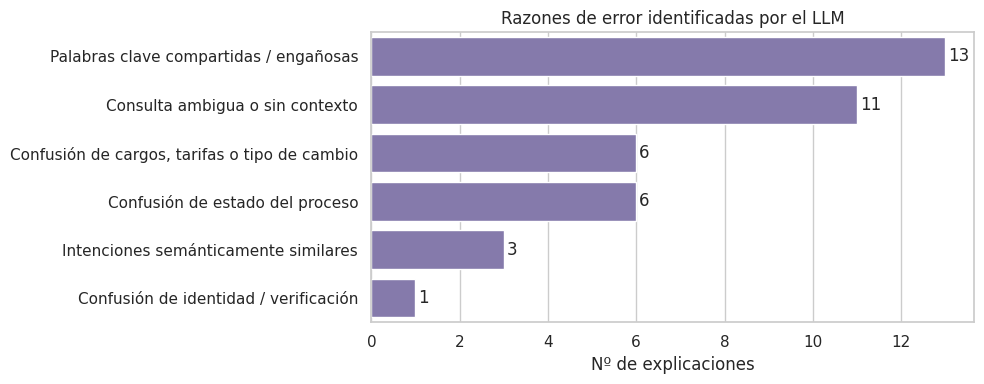


■ Confusión de cargos, tarifas o tipo de cambio (6)
   - [exchange_via_app → fiat_currency_support] The customer query is ambiguous because it is possible that they want to exchange their currency in their current account. The classifier should have considered this possibility and recognized the query as an intent for exchanging currency.
   - [reverted_card_payment? → declined_card_payment] The customer does not provide any specific details about the issue, which makes it difficult for the classifier to determine the exact problem. The words "card declined" may refer to a technical issue, but without more context, it cannot be accurately classified.
   - [receiving_money → exchange_via_app] The word "exchange" usually refers to converting currency, not withdrawing cash. Therefore, the classifier mistook the query as referring to the former and predicted the incorrect intent.
   - [exchange_charge → exchange_rate] The customer is asking about the exchange rate, which is a general ques

In [31]:
if RUN_LLM:
    reasons = llm_results.explode("razones")
    freq = reasons["razones"].value_counts()
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=freq.values, y=freq.index, ax=ax, color="#8172B3")
    ax.bar_label(ax.containers[0], padding=2); ax.set_xlabel("Nº de explicaciones"); ax.set_ylabel("")
    ax.set_title("Razones de error identificadas por el LLM")
    plt.tight_layout(); plt.show()

    for cat, grp in reasons.groupby("razones"):
        print(f"\n■ {cat} ({len(grp)})")
        for _, r in grp.iterrows():
            print(f"   - [{r['true_label']} → {r['pred_label']}] {r['clean']}")

### 4.9 Conclusiones sobre el uso del LLM para interpretar el clasificador
1. **La calibración de la decodificación es la principal defensa contra las alucinaciones.** Con temperaturas altas (≥ 1.0) el muestreo elige *tokens* poco probables: aumentan el ratio de novedad (palabras ausentes en la consulta y las etiquetas) y la repetición, y aparecen hechos inventados como plazos, montos o políticas del banco (ver el ejemplo T = 1.4 de la celda 4.4). Con temperatura 0 (decodificación codiciosa) o baja (≤ 0.3), las explicaciones se ciñen a la consulta. La configuración elegida fue **1.4 / 150**.
2. **La longitud máxima es un compromiso.** Con `max_new_tokens = 30`, una parte de las respuestas queda **truncada** a mitad de oración. Con 150 *tokens*, Falcon tiende a "seguir la conversación" (inventa un nuevo turno *User:*, añade consejos no pedidos o repite ideas). Un valor intermedio, junto con el post-procesamiento que conserva como máximo dos oraciones, da respuestas completas y breves. **5% de truncada y el 85% que cumple el límite de la tabla de calibración.**
3. **La estructura del *prompt* importa tanto como los parámetros.** La versión ingenua (v1) no conoce la clase correcta y suele justificar la predicción errónea o responder con generalidades. Las reglas explícitas (v2) y, sobre todo, el ejemplo *few-shot* (v3) fijan el formato (citar las palabras de la consulta y contrastar las dos intenciones) y mejoran el puntaje compuesto. **El mayor score es el de v3 con 0.77, seguido de V1 con 0.66 y al final V2 con 0.59**
4. **Razones que identifica el LLM.** Las explicaciones de los 20 errores se agrupan sobre todo en **Confusión de cargos, tarifas o tipos de cambio, Confusión de estado del proceso, Confusión de identidad, Consulta ambigua o sin contexto, Semántica similar y Palabras clave compartidas**. Estas razones coinciden con el análisis cuantitativo de la sección 3.5: palabras compartidas entre intenciones vecinas, consultas sin contexto suficiente y confusión sobre el estado del proceso (pendiente, fallido o revertido).
5. **Utilidad y límites.** El LLM sirve como herramienta de **interpretación en lenguaje natural** que ayuda a un analista a formular hipótesis sobre los errores. Sin embargo, sus explicaciones son **racionalizaciones *post hoc***: Falcon no tiene acceso a los pesos ni a la atención de DistilRoBERTa, sino que infiere una razón plausible a partir del texto y de las dos etiquetas. Por eso deben tratarse como hipótesis y validarse manualmente, como en la celda 4.7 (**85% coherentes, 95% Pertinentes y 75% con Alucinación**). Además, un modelo de 7 B parámetros cuantizado a 4 bits sigue cometiendo errores de razonamiento, y su costo de inferencia es varios órdenes de magnitud mayor que el del clasificador.

## 5. Conclusiones generales
- **El problema es de separabilidad semántica fina.** El EDA mostró textos cortos, un vocabulario pequeño y compartido entre clases, y un desbalance moderado que no afecta el desempeño. El análisis de errores confirmó que los fallos se deben a intenciones vecinas con alto solapamiento léxico y a etiquetas ambiguas, no a la falta de datos (ρ ≈ 0 entre soporte y F1).
- **El *transfer learning* con Transformers es muy eficaz para la clasificación de intenciones.** Un modelo destilado de 82 M parámetros, ajustado durante 5 épocas efectivas, logra 93.15 % de *accuracy* sobre 77 clases, en línea con el estado del arte reportado para Banking77.
- **Clasificador y LLM se complementan.** El Transformer ajustado es rápido, barato y preciso para decidir la clase; el LLM generativo aporta **explicaciones legibles** de los errores y ayuda a diagnosticar el modelo, siempre que se controle con un *prompt* estructurado, temperatura baja, una longitud acotada y validación humana.
- **Las alucinaciones se mitigan, pero no se eliminan.** Ni la calibración ni el *prompt* garantizan veracidad; la revisión manual y las métricas de *grounding* siguen siendo necesarias antes de usar las explicaciones de un LLM para tomar decisiones.

## 6. Referencias
- Almazrouei, E., et al. (2023). *The Falcon Series of Open Language Models*. arXiv:2311.16867.
- Casanueva, I., Temčinas, T., Gerz, D., Henderson, M., & Vulić, I. (2020). Efficient Intent Detection with Dual Sentence Encoders. *Proc. 2nd Workshop on NLP for ConvAI, ACL 2020*. arXiv:2003.04807.
- Dettmers, T., Pagnoni, A., Holtzman, A., & Zettlemoyer, L. (2023). QLoRA: Efficient Finetuning of Quantized LLMs. *NeurIPS 2023*. arXiv:2305.14314.
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *NAACL-HLT 2019*.
- Holtzman, A., Buys, J., Du, L., Forbes, M., & Choi, Y. (2020). The Curious Case of Neural Text Degeneration. *ICLR 2020*.
- Ji, Z., et al. (2023). Survey of Hallucination in Natural Language Generation. *ACM Computing Surveys, 55*(12).
- Liu, Y., et al. (2019). RoBERTa: A Robustly Optimized BERT Pretraining Approach. arXiv:1907.11692.
- Loshchilov, I., & Hutter, F. (2019). Decoupled Weight Decay Regularization. *ICLR 2019*.
- Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter. arXiv:1910.01108.
- Vaswani, A., et al. (2017). Attention Is All You Need. *NeurIPS 2017*.
- Wolf, T., et al. (2020). Transformers: State-of-the-Art Natural Language Processing. *EMNLP 2020: System Demonstrations*.
- Hugging Face. *PolyAI/banking77* dataset card. https://huggingface.co/datasets/PolyAI/banking77
- Hugging Face. *tiiuae/falcon-7b-instruct* model card. https://huggingface.co/tiiuae/falcon-7b-instruct
- Hugging Face. *distilroberta-base* model card. https://huggingface.co/distilroberta-base